In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import scikitplot as skplt
from collections import defaultdict

from utils.model_inference_plots import *
from scipy.ndimage import label, find_objects

In [2]:
# Loads the data for THEMIS E testing
df = pd.read_parquet('data/v80/final_model_data_the_scaled.parquet')
df[['Event_class', '|V_perp|']] = pd.read_parquet('data/v80/final_matrix_the_perp_labeled_v80.parquet')[['Event_class', '|V_perp|']][2:].reset_index(drop=True)
event_df = pd.read_csv('data/event_data_all_perp_80_avg.csv').query("satellite_name == 'THEMIS E'").reset_index(drop=True)

In [3]:
df.index = range(2, len(df) + 2)

In [4]:
df.shape

(16721136, 20)

In [5]:
continuous_sequences = df.groupby((df['Epoch_time'].diff() > 300).cumsum()).apply(lambda x: list(x.index)).values

In [6]:
X_test = df[['Bx', 'By', 'Bz', 'Bx_lag_1', 'Bx_lag_2', 'By_lag_1',
             'By_lag_2', 'Bz_lag_1', 'Bz_lag_2', 'Bx_conditional_vol',
             'By_conditional_vol', 'Bz_conditional_vol', 'Bx_rolling_stdev',
             'By_rolling_stdev', 'Bz_rolling_stdev']].values

y_test = df['Event_label_80'].values

In [7]:
df['Time'] = pd.to_datetime(df['Epoch_time'], unit='s', utc=True)

In [8]:
test_size = len(X_test)
n_features = X_test.shape[1]

In [9]:
y_pred_probas = np.load("models/bilstm_runs/mosrl_80_the_pred_probas.npy")

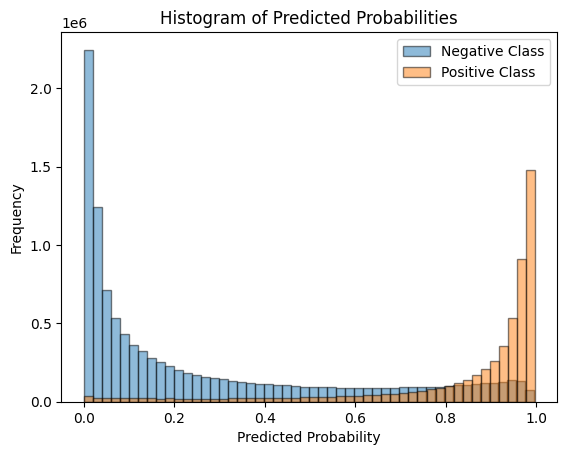

In [10]:
plt.figure(dpi=100)
plt.hist(y_pred_probas[y_test == 0], bins=50, alpha=0.5, label='Negative Class', edgecolor='black')
plt.hist(y_pred_probas[y_test == 1], bins=50, alpha=0.5, label='Positive Class', edgecolor='black')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities')
plt.legend()
plt.show()

In [11]:
threshold = 0.6
y_pred = (y_pred_probas >= threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87  11131422
           1       0.71      0.87      0.78   5589714

    accuracy                           0.83  16721136
   macro avg       0.82      0.84      0.82  16721136
weighted avg       0.85      0.83      0.84  16721136



In [12]:
df['Event_pred_probas'] = y_pred_probas
df['Event_pred'] = y_pred

In [13]:
df['Time_diff'] = df['Time'].diff().dt.total_seconds().fillna(0)

In [14]:
# Iterates and gets all event indices in THEMIS E
tha_start_time = (pd.to_datetime(event_df['start_time']).astype('int64') / 10**9).values
tha_end_time = (pd.to_datetime(event_df['end_time']).astype('int64') / 10**9).values

event_indices = []

for idx, row in event_df.iterrows():
    start_idx = np.searchsorted(df['Epoch_time'], tha_start_time[idx], side='left')
    end_idx = np.searchsorted(df['Epoch_time'], tha_end_time[idx], side='right')

    event_indices.append(df.iloc[start_idx:end_idx].index.values)

In [15]:
# Calculates ratio of captured timesteps to all timesteps in event intervals
ratios_by_class = defaultdict(list)

for i, indices in enumerate(event_indices):
    group = df.loc[indices]
    
    true_label = group['Event_label_80'].values
    pred_label = group['Event_pred'].values
    cls = group['Event_class'].iloc[0]

    N_j = np.sum(true_label)
    Nt_j = np.sum(pred_label == 1)

    ratio = Nt_j / N_j
    ratios_by_class[cls].append(ratio)

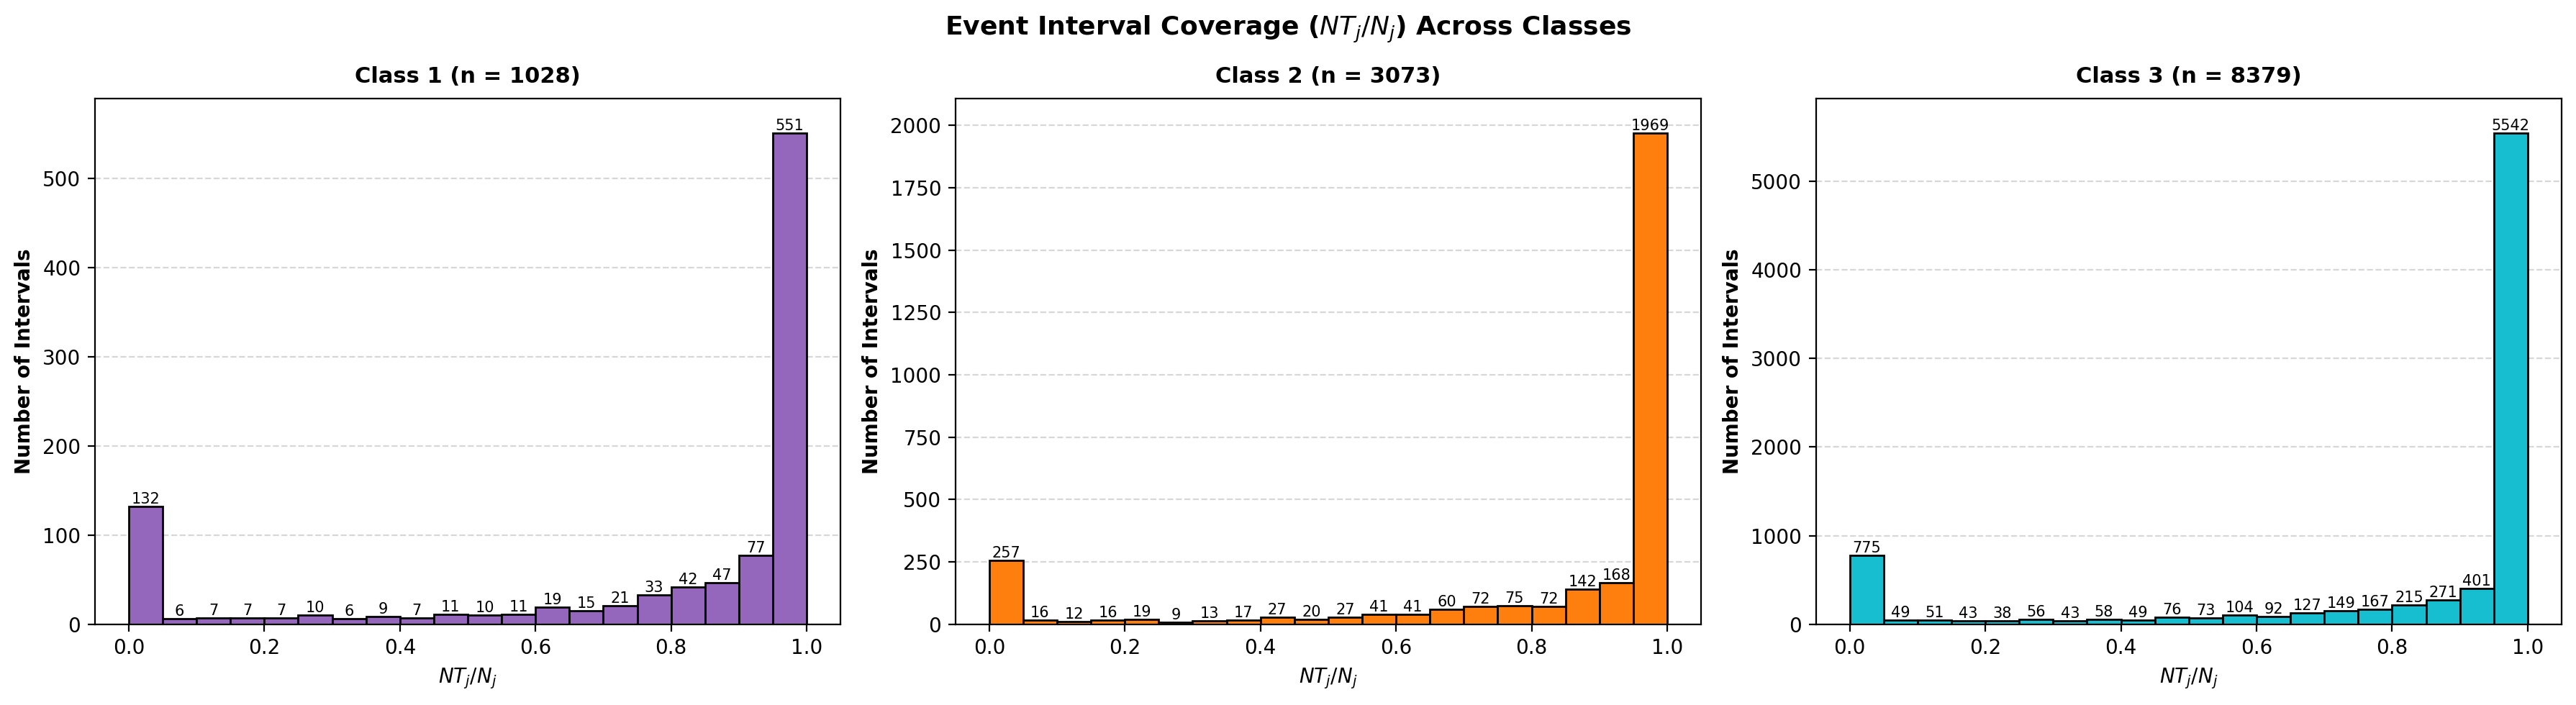

In [16]:
class_colors = {1: "C4", 2: "C1", 3: "C9"}
sorted_items = sorted(ratios_by_class.items())

# sharey=False (default) gives each subplot its own independent y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=200)

for ax, (cls, ratios) in zip(axes, sorted_items):
    hist_color = class_colors.get(int(cls), "C0")

    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    counts, bins, patches = ax.hist(
        ratios,
        edgecolor="black",
        bins=20,
        color=hist_color,
        alpha=1.0,
        linewidth=1.0,
    )

    bin_width = bins[1] - bins[0]
    for count, bin_edge in zip(counts, bins[:-1]):
        if count > 0:
            ax.text(
                bin_edge + bin_width / 2,
                count,
                str(int(count)),
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

    ax.set_xlabel(r"$NT_j / N_j$", fontweight="bold", fontsize=10)
    ax.set_ylabel("Number of Intervals", fontweight="bold", fontsize=10)
    ax.set_title(
        f"Class {cls} (n = {len(ratios)})",
        fontweight="bold",
        fontsize=11,
        pad=8,
    )

    # Add 12% headroom so top counts don't clip against the upper frame
    ax.set_ylim(0, max(counts) * 1.07)

fig.suptitle(
    r"Event Interval Coverage ($NT_j / N_j$) Across Classes",
    fontweight="bold",
    fontsize=13,
    y=0.97,
)

plt.tight_layout()
plt.show()

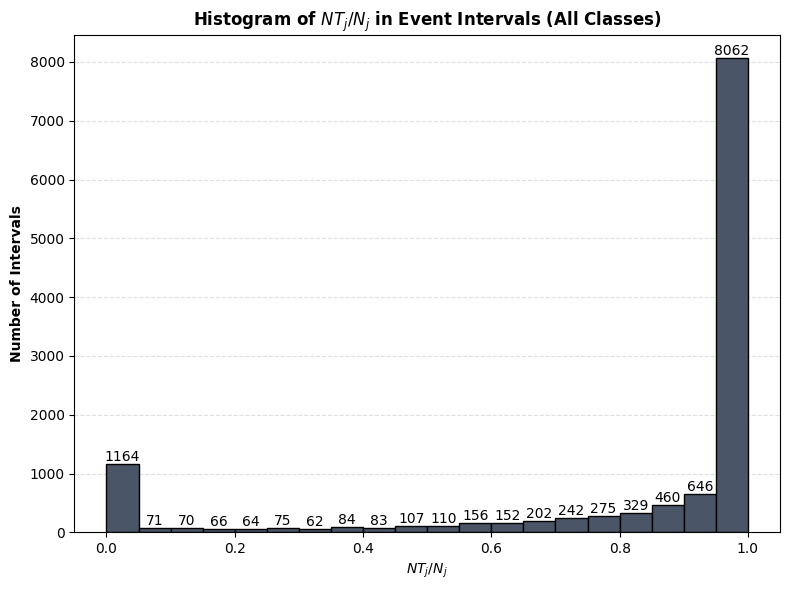

In [17]:
plt.figure(figsize=(8, 6), dpi=100)

plt.gca().set_axisbelow(True)
plt.grid(axis="y", linestyle="--", alpha=0.4)

counts, bins, patches = plt.hist(
    sum(ratios_by_class.values(), []),
    bins=20,
    edgecolor="black",
    color="#4a5568",  # Slate Steel Gray
    alpha=1.0,  # Fully opaque to block background grid lines
)

bin_width = bins[1] - bins[0]
for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(
            bin_edge + bin_width / 2,
            count,
            str(int(count)),
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.xlabel(r"$NT_j / N_j$", fontweight="bold")
plt.ylabel("Number of Intervals", fontweight="bold")
plt.title(
    "Histogram of $NT_j / N_j$ in Event Intervals (All Classes)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [18]:
# print ratio of < 0.05 / 12480 and ratio of > 0.95 / 12480
total_intervals = sum(len(ratios) for ratios in ratios_by_class.values())
ratio_below_005 = sum(1 for ratios in ratios_by_class.values() for r in ratios if r < 0.05) / total_intervals
ratio_above_095 = sum(1 for ratios in ratios_by_class.values() for r in ratios if r > 0.95) / total_intervals

print(f"Fully missed events: {ratio_below_005 * 100:.2f}%")
print(f"Fully captured events: {ratio_above_095 * 100:.2f}%")

Fully missed events: 9.33%
Fully captured events: 64.60%


In [19]:
# Extracts the total number of events per year and by class while keeping track of the missed 
# and captured events
ratios_by_year_class = defaultdict(list)

event_years = pd.to_datetime(event_df['start_time']).dt.year.values
event_classes = event_df['event_class'].values

for i, indices in enumerate(event_indices):
    group = df.loc[indices]

    true_label = group['Event_label_80'].values
    pred_label = group['Event_pred'].values
    year = event_years[i]
    cls = event_classes[i]

    N_j = np.sum(true_label)
    Nt_j = np.sum(pred_label == 1)

    if N_j > 0:
        ratio = Nt_j / N_j
        ratios_by_year_class[(year, cls)].append(ratio)

low_high_ratios = defaultdict(dict)

for (year, cls), ratios in ratios_by_year_class.items():
    low_count = sum(r < 0.05 for r in ratios)
    high_count = sum(r > 0.95 for r in ratios)
    if high_count > 0:
        low_high_ratios[cls][year] = low_count / high_count

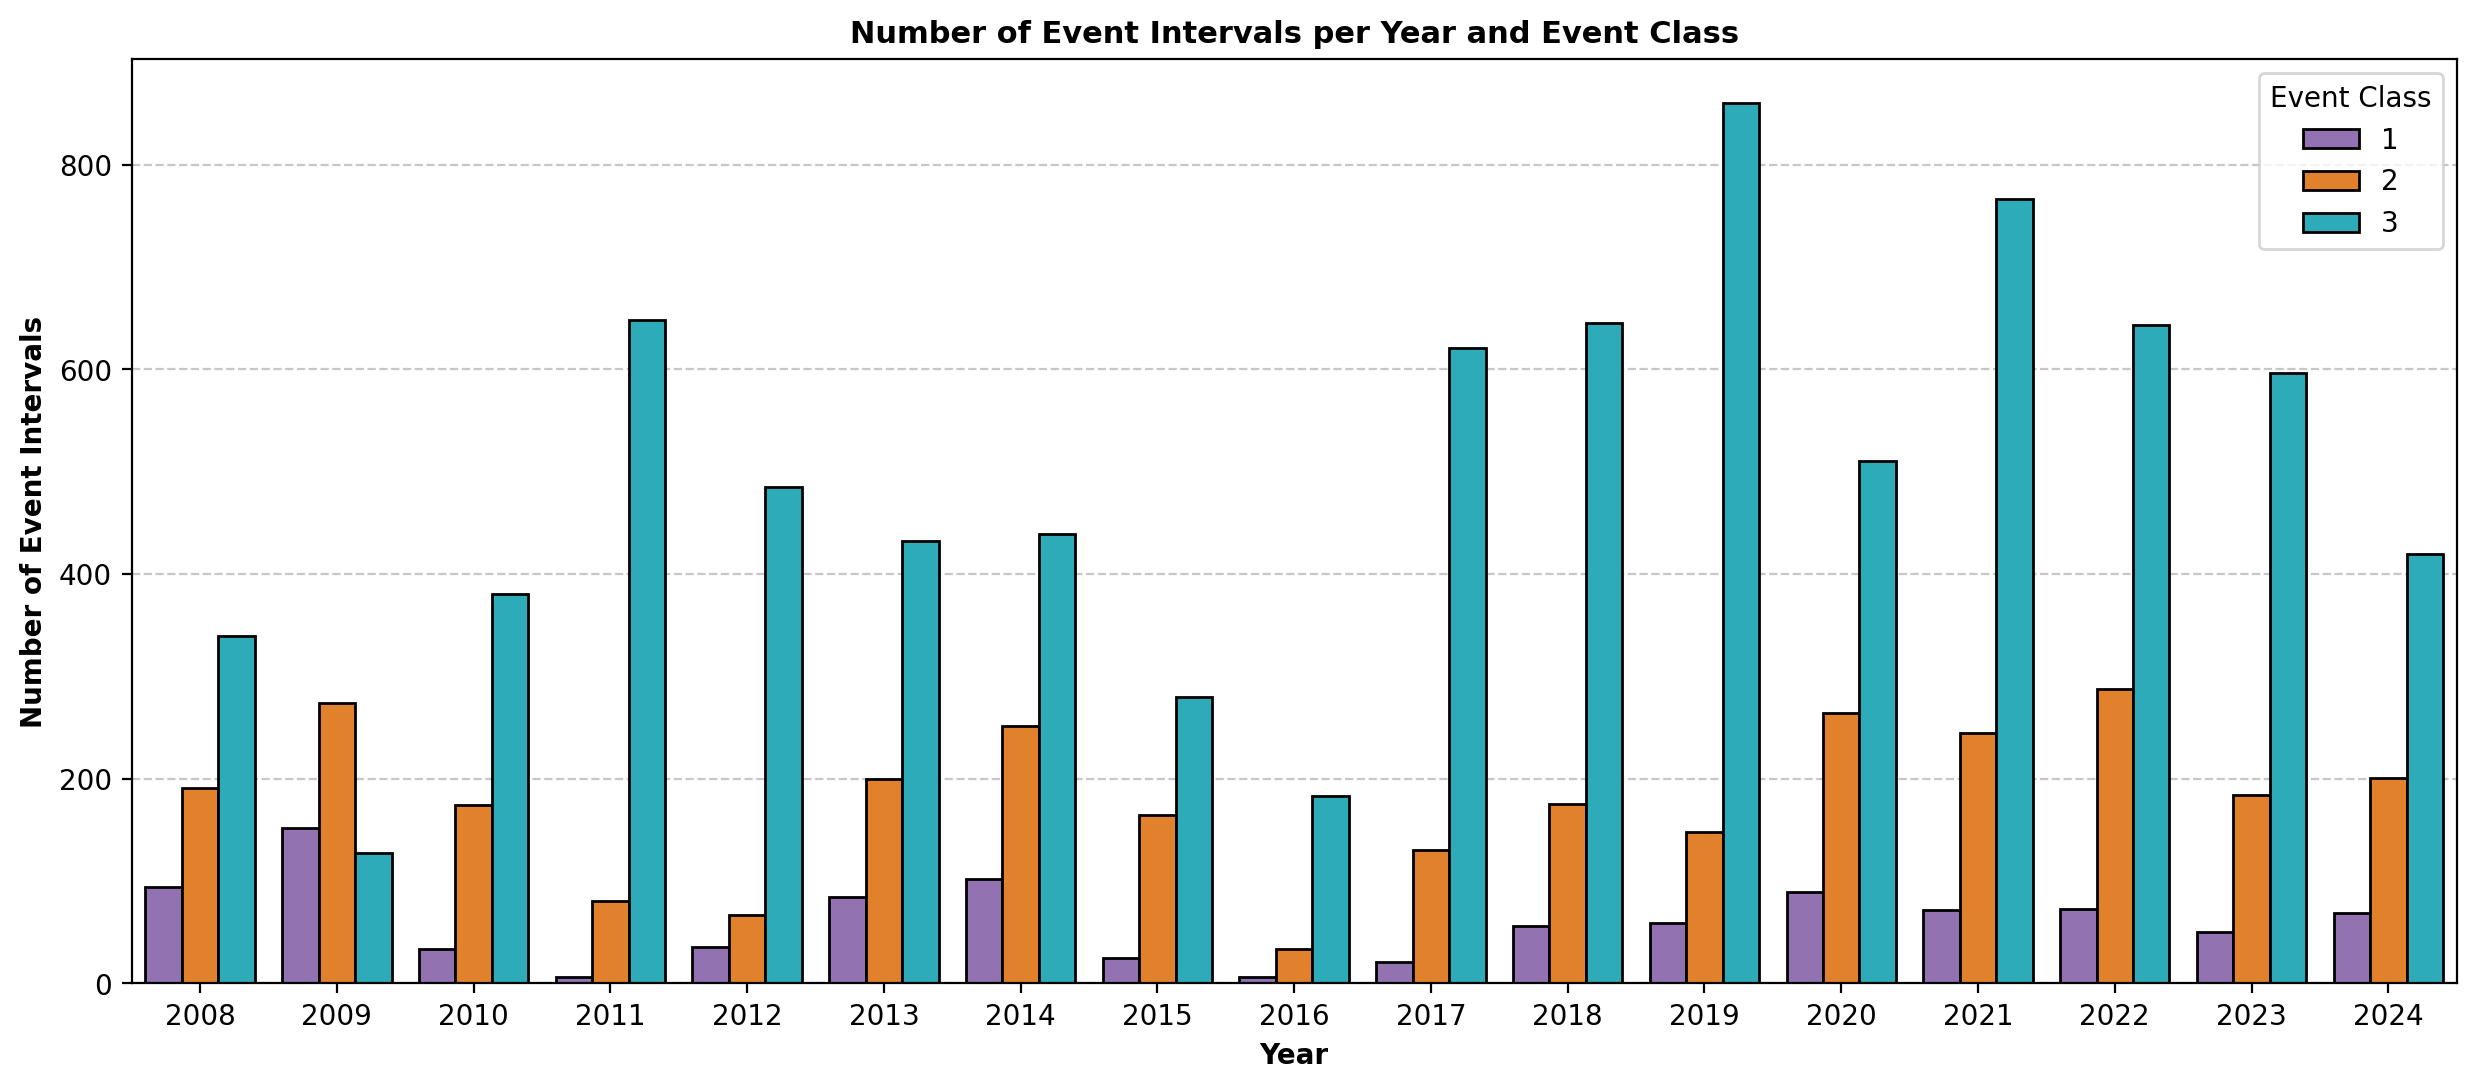

In [20]:
# Bar plot over time to visualize number of events in each year
event_years = pd.to_datetime(event_df['start_time']).dt.year.values
event_classes = event_df['event_class'].values
colors = {1: "C4", 2: "C1", 3: "C9"}
event_interval_counts = defaultdict(int)

for year, cls in zip(event_years, event_classes):
    if year != 2025:
        event_interval_counts[(year, cls)] += 1

counts_df = pd.DataFrame([
    {'Year': year, 'Event_class': cls, 'Event_count': count}
    for (year, cls), count in event_interval_counts.items()
])

plt.figure(figsize=(15, 6), dpi=200)
sns.barplot(x='Year', y='Event_count', hue='Event_class', data=counts_df, palette=colors, edgecolor='black')
plt.title('Number of Event Intervals per Year and Event Class', fontweight='bold', fontsize=11)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Number of Event Intervals', fontweight='bold')
plt.legend(title='Event Class')
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

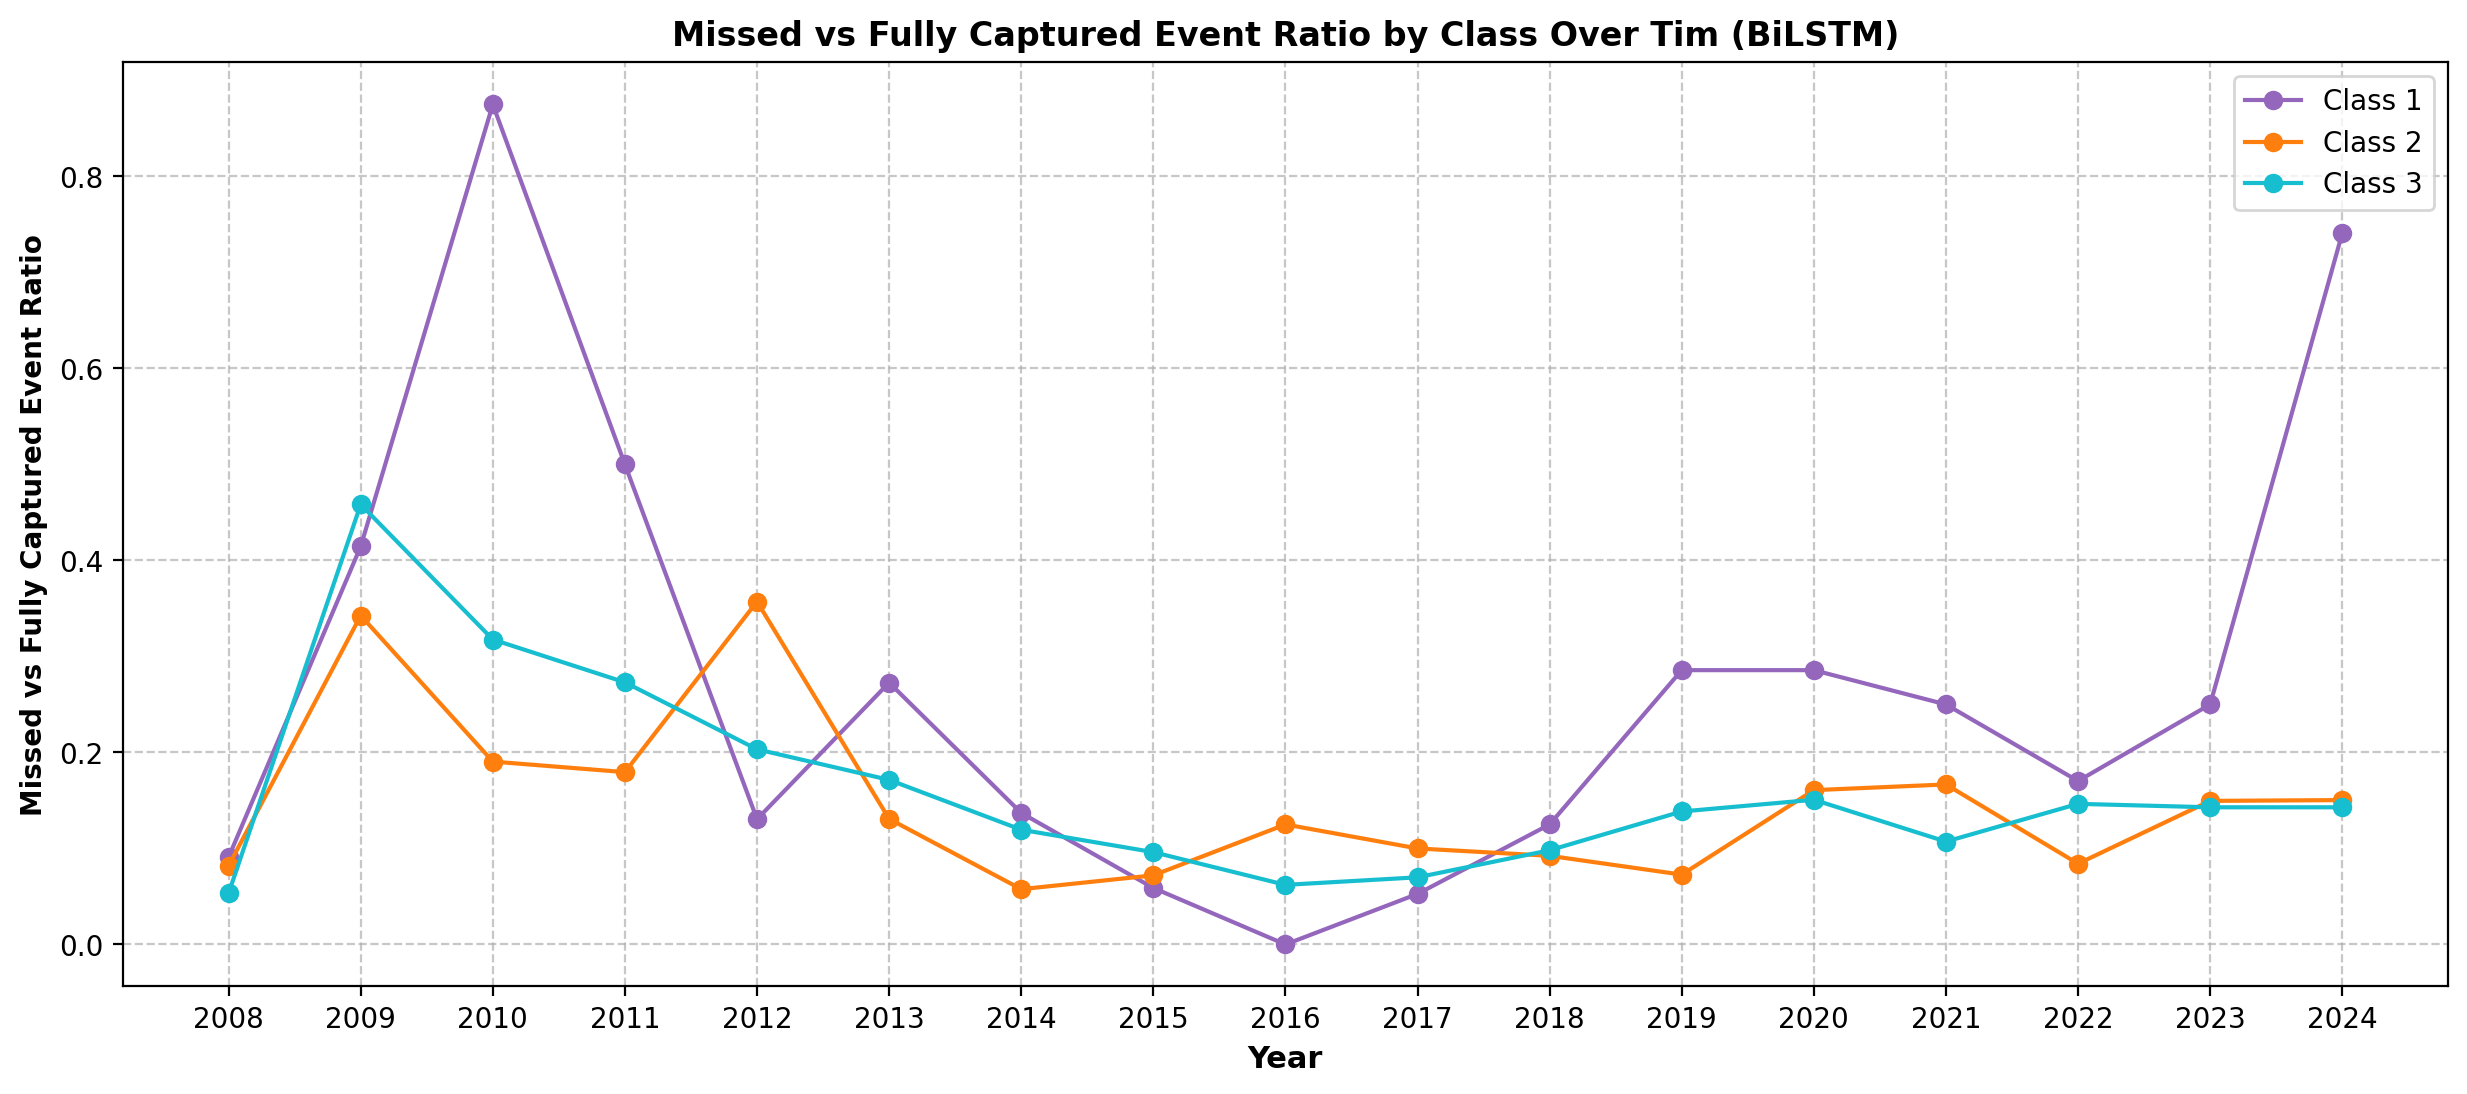

In [21]:
# Line plots to visualize the ratio of missed to captured events over time
plt.figure(figsize=(15, 6), dpi=200)
colors = ['C4', 'C1', 'C9']
for idx, (cls, year_ratio_dict) in enumerate(sorted(low_high_ratios.items())):
    years = sorted(year_ratio_dict.keys())
    values = [year_ratio_dict[y] for y in years]
    plt.plot(years, values, label=f'Class {cls}', marker='o', color=colors[idx])

plt.xlabel('Year', fontweight='bold', fontsize=11)
plt.ylabel('Missed vs Fully Captured Event Ratio', fontweight='bold')
plt.title('Missed vs Fully Captured Event Ratio by Class Over Tim (BiLSTM)', fontweight='bold')
plt.xticks(list(range(2008, 2025)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

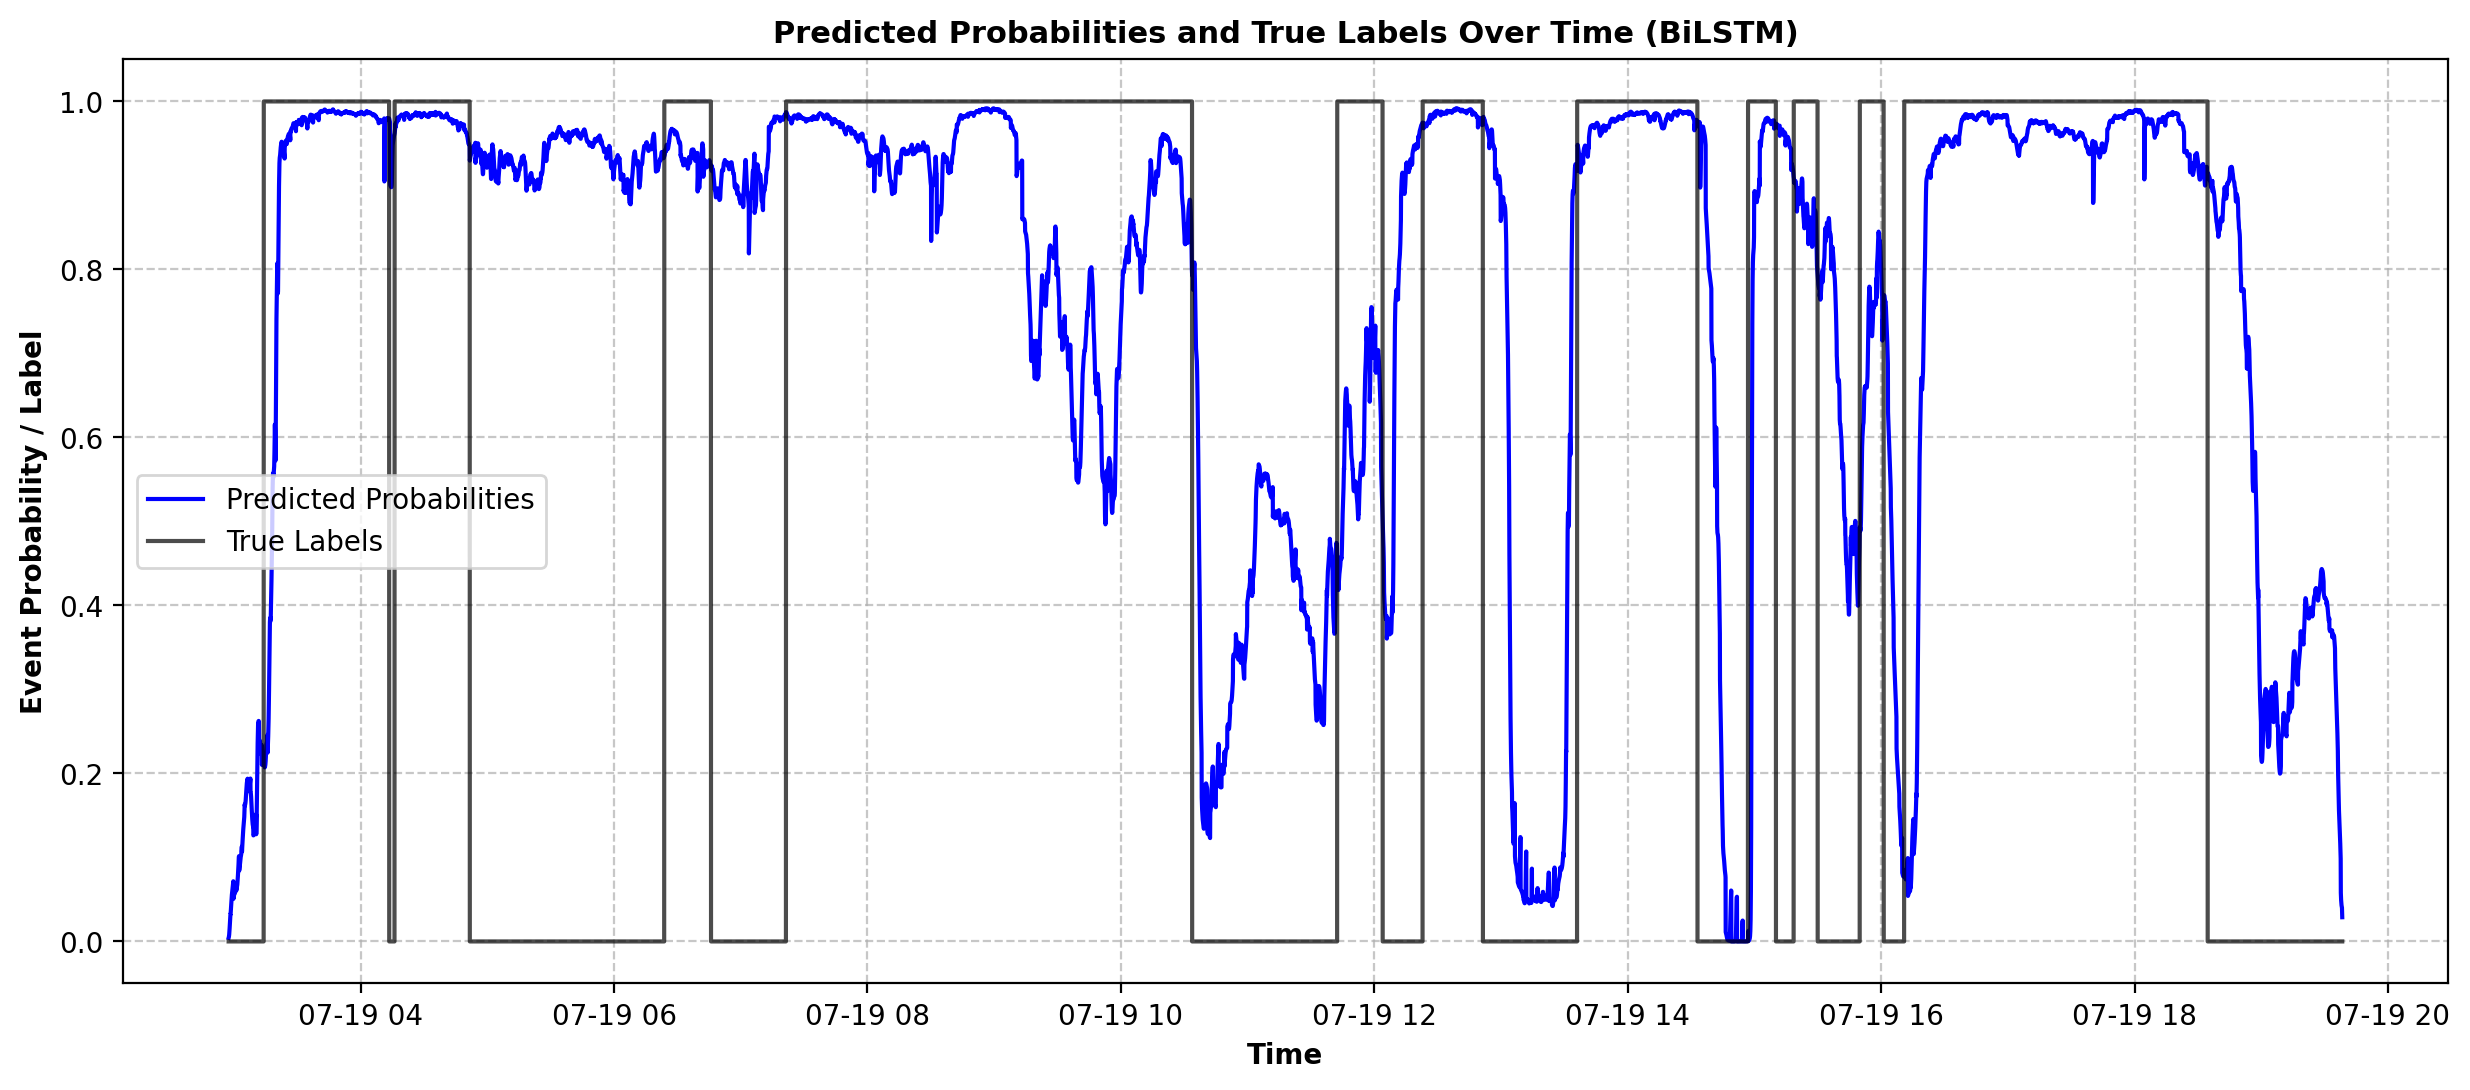

In [22]:
# find and plot a whole a continuous sequence of predicted probabilities and true labels over time
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(df['Time'][12911906:12926751], df['Event_pred_probas'][12911906:12926751], label='Predicted Probabilities', color='blue')
plt.plot(df['Time'][12911906:12926751], df['Event_label_80'][12911906:12926751], label='True Labels', color='black', alpha=0.7)
plt.xlabel('Time', fontweight='bold')
plt.ylabel('Event Probability / Label', fontweight='bold')
plt.title('Predicted Probabilities and True Labels Over Time (BiLSTM)', fontweight='bold', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [23]:
# where event = 1 and pred_probas is between 0.3 and 0.6
df_uncertain = df[(df['Event_label_80'] == 1) & (df['Event_pred_probas'] >= 0.3) & (df['Event_pred_probas'] <= 0.6)]
print(f"Number of uncertain time steps: {len(df_uncertain)}")

Number of uncertain time steps: 390630


In [24]:
df_certain = df[(df['Event_label_80'] == 1) &(df['Event_pred_probas'] >= 0.6)]
print(f"Number of certain time steps: {len(df_certain)}")

Number of certain time steps: 4856330


In [25]:
df_non = df[(df['Event_label_80'] == 0)]
print(f"Number of non-event time steps: {len(df_non)}")

Number of non-event time steps: 11131422


In [26]:
df_false = df[(df['Event_label_80'] == 0) & (df['Event_pred_probas'] >= 0.6)]
print(f"Number of false event time steps: {len(df_false)}")

Number of false event time steps: 2031490


In [27]:
# get the mean NT_j / N_j across all event intervals
all_ratios = sum(ratios_by_class.values(), [])
mean_ratio = np.mean(all_ratios)
print(f"Mean NT_j / N_j across all event intervals: {mean_ratio:.3f}")

Mean NT_j / N_j across all event intervals: 0.824


In [28]:
# skplt.metrics.plot_roc(y_test, np.column_stack([1 - y_pred_probas, y_pred_probas]), figsize=(8, 6))
# plt.show()

In [29]:
# # precision recall curve for the positive class
# skplt.metrics.plot_precision_recall(y_test, np.column_stack([1 - y_pred_probas, y_pred_probas]), figsize=(8, 6))
# plt.show()

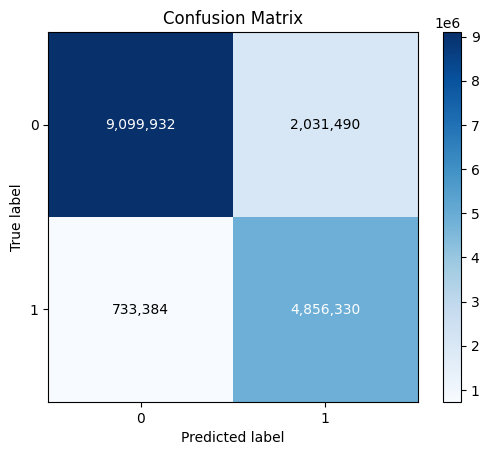

In [30]:
ax = skplt.metrics.plot_confusion_matrix(
    y_test, 
    y_pred, 
    normalize=False, 
    title="Confusion Matrix",
    cmap="Blues"
)

# 2. Iterate through the matrix text annotations and reformat with commas
for text in ax.images[0].axes.texts:
    try:
        val = int(text.get_text())
        text.set_text(f"{val:,}") # Adds comma formatting (e.g., 10000 -> 10,000)
    except ValueError:
        pass  # Skip any text that can't be converted to an integer

plt.show()

In [31]:
pred_mask = (y_pred_probas >= 0.6).flatten().astype(int)
y_test_flat = np.asarray(y_test).flatten().astype(bool)

pred_regions, n_pred = label(pred_mask, structure=np.ones(3, dtype=int))

min_duration = 200  # 10 minutes

# 1. Total samples per region (index 0 is the background)
durations = np.bincount(pred_regions, minlength=n_pred + 1)

# 2. True positives per region (count label occurrences where y_test is True)
true_positives = np.bincount(pred_regions[y_test_flat], minlength=n_pred + 1)

# 3. Vectorized mask: exclude background (index > 0), check zero overlap and duration
valid_mask = (durations >= min_duration) & (true_positives == 0)
valid_mask[0] = False  # Ignore background label 0

# Extract matching region IDs and their durations
matched_ids = np.flatnonzero(valid_mask)
matched_durations = durations[matched_ids]

# 4. Construct output dictionary list
false_events = [
    {
        'region_id': int(reg_id),
        'duration': int(dur),
        'duration_min': dur * 3 / 60
    }
    for reg_id, dur in zip(matched_ids, matched_durations)
]

In [32]:
MIN_TRUE_FRACTION = 0.5
MIN_TRUE_TIMESTEPS = 60
MIN_PERFECT_DURATION = 200  # at least 10 minutes

tp = true_positives[1:]
dur = durations[1:]
frac = np.where(dur > 0, tp / dur, 0.0)

is_sustained = dur >= 200
has_overlap = tp > 0

# --- Sub-scale intervals (< 200 steps / < 10 min) ---
short_false = (~has_overlap) & (~is_sustained)
micro_pred = (has_overlap) & (~is_sustained)

# --- Sustained intervals (>= 200 steps / >= 10 min) ---
sustained_false = (~has_overlap) & (is_sustained)
perfect = (
    (tp == dur) & (is_sustained)
)
genuine_mixed = (
    (is_sustained)
    & ~perfect
    & (tp >= MIN_TRUE_TIMESTEPS)
    & (frac >= MIN_TRUE_FRACTION)
)
effectively_false = (
    (is_sustained) & (has_overlap) & ~perfect & ~genuine_mixed
)

print(f"Perfect:            {perfect.sum()}")
print(f"Genuine mixed:      {genuine_mixed.sum()}")
print(f"Effectively false:  {effectively_false.sum()}")
print(f"Micro-predictions:  {micro_pred.sum()}")
print(f"Short false:        {short_false.sum()}")
print(f"Sustained false:    {sustained_false.sum()}")

Perfect:            644
Genuine mixed:      5732
Effectively false:  855
Micro-predictions:  1899
Short false:        3797
Sustained false:    960


In [33]:
y_pred_flat = y_pred_probas.flatten()

def build_region_df(region_ids):
    region_ids = np.asarray(region_ids)
    
    # get all indices for all regions at once
    region_mask = np.isin(pred_regions, region_ids)
    all_indices = np.where(region_mask)[0]
    region_labels = pred_regions[all_indices]
    
    # precompute all needed columns as arrays
    bx_vol   = df['Bx_conditional_vol'].values
    by_vol   = df['By_conditional_vol'].values
    bz_vol   = df['Bz_conditional_vol'].values
    lim_4    = df['Bx_rolling_stdev'].values
    lim_8    = df['By_rolling_stdev'].values
    lim_64   = df['Bz_rolling_stdev'].values
    vperp    = df['|V_perp|'].values
    
    # group by region using bincount-style aggregation
    counts   = np.bincount(region_labels, minlength=region_ids.max()+1)
    sum_bx   = np.bincount(region_labels, weights=bx_vol[all_indices], minlength=region_ids.max()+1)
    sum_by   = np.bincount(region_labels, weights=by_vol[all_indices], minlength=region_ids.max()+1)
    sum_bz   = np.bincount(region_labels, weights=bz_vol[all_indices], minlength=region_ids.max()+1)
    sum_l4   = np.bincount(region_labels, weights=lim_4[all_indices], minlength=region_ids.max()+1)
    sum_l8   = np.bincount(region_labels, weights=lim_8[all_indices], minlength=region_ids.max()+1)
    sum_l64  = np.bincount(region_labels, weights=lim_64[all_indices], minlength=region_ids.max()+1)
    sum_pred = np.bincount(region_labels, weights=y_pred_flat[all_indices], minlength=region_ids.max()+1)
    sum_vp   = np.bincount(region_labels, weights=vperp[all_indices], minlength=region_ids.max()+1)
    
    # max pred prob per region
    max_pred = np.full(region_ids.max()+1, -np.inf)
    np.maximum.at(max_pred, region_labels, y_pred_flat[all_indices])
    
    # start/end indices per region
    start_idx = np.full(region_ids.max()+1, np.inf)
    end_idx   = np.zeros(region_ids.max()+1, dtype=int)
    np.minimum.at(start_idx, region_labels, all_indices)
    np.maximum.at(end_idx,   region_labels, all_indices)
    
    # build dataframe for requested region_ids only
    c = counts[region_ids]
    return pd.DataFrame({
        'region_id':      region_ids,
        'duration_min':   durations[region_ids] * 3 / 60,
        'start_idx':      start_idx[region_ids].astype(int),
        'end_idx':        end_idx[region_ids],
        'true_timesteps': true_positives[region_ids].astype(int),
        'mean_bx_vol':    sum_bx[region_ids]   / c,
        'mean_by_vol':    sum_by[region_ids]   / c,
        'mean_bz_vol':    sum_bz[region_ids]   / c,
        'mean_lim_4':     sum_l4[region_ids]   / c,
        'mean_lim_8':     sum_l8[region_ids]   / c,
        'mean_lim_64':    sum_l64[region_ids]  / c,
        'mean_pred_prob': sum_pred[region_ids] / c,
        'max_pred_prob':  max_pred[region_ids],
        '|V_perp|_mean':  sum_vp[region_ids]   / c,
    })

In [34]:
short_false_timesteps = (durations[1:] * short_false).sum()
print(f"Short false timesteps: {short_false_timesteps}")

Short false timesteps: 161142


In [35]:
genuine_mixed_ids = np.flatnonzero(genuine_mixed) + 1
effectively_false_ids = np.flatnonzero(effectively_false) + 1
short_false_ids = np.flatnonzero(short_false) + 1
micro_pred_ids = np.flatnonzero(micro_pred) + 1
sustained_false_ids = np.flatnonzero(sustained_false) + 1

genuine_mixed_df = build_region_df(genuine_mixed_ids)
effectively_false_df = build_region_df(effectively_false_ids)
short_false_df = build_region_df(short_false_ids)
micro_pred_df = build_region_df(micro_pred_ids)
sustained_false_df = build_region_df(sustained_false_ids)

In [ ]:
# dfs = {
#     "Genuine Mixed": genuine_mixed_df,
#     "Effectively False": effectively_false_df,
#     "Short False": short_false_df,
#     "Micro-predictions": micro_pred_df,
#     "Sustained False": sustained_false_df,
# }

# records = []
# TOTAL_FP_BASELINE = 2_026_788

# for name, df in dfs.items():
#     n_intervals = len(df)

#     timesteps = ((df["end_idx"] - df["start_idx"]) + 1).sum()

#     if name in ["Short False", "Sustained False"]:
#         tp = 0
#         fp = timesteps
#     elif "true_timesteps" in df.columns:
#         tp = df["true_timesteps"].sum()
#         fp = timesteps - tp
#     else:
#         tp = df["true_positives"].sum()
#         fp = timesteps - tp

#     records.append(
#         {
#             "Category": name,
#             "Intervals (N)": n_intervals,
#             "Total Steps": timesteps,
#             "True Steps (TP)": tp,
#             "False Steps (FP)": fp,
#             "FP Share (%)": (fp / TOTAL_FP_BASELINE) * 100,
#             "Interval Purity (%)": (tp / timesteps * 100) if timesteps > 0 else 0,
#         }
#     )

# summary_table = pd.DataFrame(records)
# print(summary_table.to_string(index=False))

         Category  Intervals (N)  Total Steps  True Steps (TP)  False Steps (FP)  FP Share (%)  Interval Purity (%)
    Genuine Mixed           5732      5229232          4185573           1043659     51.493249            80.041830
Effectively False            855       692171           250921            441250     21.770901            36.251302
      Short False           3797       161142                0            161142      7.950610             0.000000
Micro-predictions           1899       113130           102210             10920      0.538784            90.347388
  Sustained False            960       374519                0            374519     18.478450             0.000000


In [37]:
fn_records = []
for indices in event_indices:
    grp = df.loc[indices]
    n_true = np.sum(grp["Event_label_80"].values)
    n_pred = np.sum(grp["Event_pred"].values == 1)
    ratio = n_pred / n_true if n_true > 0 else 0.0

    if ratio > 0.95:
        cat = "Fully Captured (>95%)"
    elif ratio > 0.70:
        cat = "Mostly Captured (70-95%)"
    elif ratio > 0.40:
        cat = "Partially Captured (40-70%)"
    elif ratio > 0.05:
        cat = "Mostly Missed (5-40%)"
    else:
        cat = "Fully Missed (≤5%)"

    fn_records.append(
        {
            "category": cat,
            "ratio": ratio,
            "duration_min": len(indices) * 3 / 60,
            "mean_bx_vol": grp["Bx_conditional_vol"].mean(),
            "mean_by_vol": grp["By_conditional_vol"].mean(),
            "mean_bz_vol": grp["Bz_conditional_vol"].mean(),
            "mean_lim_4": grp["Bx_rolling_stdev"].mean(),
            "mean_lim_8": grp["By_rolling_stdev"].mean(),
            "mean_lim_64": grp["Bz_rolling_stdev"].mean(),
            "mean_pred_prob": grp["Event_pred_probas"].mean(),
            "|V_perp|_mean": grp["|V_perp|"].mean(),
        }
    )

fn_df = pd.DataFrame(fn_records)
fully_captured_df = fn_df[
    fn_df["category"] == "Fully Captured (>95%)"
].reset_index(drop=True)

In [38]:
def summarize_regimes(sub_df, name):
    prob = sub_df["mean_pred_prob"]
    q = prob.quantile([0.05, 0.25, 0.50, 0.75, 0.95]).to_dict()

    bx_vol = sub_df["mean_bx_vol"].median()
    by_vol = sub_df["mean_by_vol"].median()
    bz_vol = sub_df["mean_bz_vol"].median()
    
    # Updated scales: 4, 8, 64
    lim4 = sub_df["mean_lim_4"].median() if "mean_lim_4" in sub_df.columns else sub_df["LIM_scale_4_log"].median()
    lim8 = sub_df["mean_lim_8"].median() if "mean_lim_8" in sub_df.columns else sub_df["LIM_scale_8_log"].median()
    lim64 = sub_df["mean_lim_64"].median() if "mean_lim_64" in sub_df.columns else sub_df["LIM_scale_64_log"].median()

    return {
        "Category": name,
        "Count": len(sub_df),
        "Median dur (min)": sub_df["duration_min"].median(),
        "Median Bx_vol": bx_vol,
        "Median By_vol": by_vol,
        "Median Bz_vol": bz_vol,
        "Median Bx_std": lim4,
        "Median By_std": lim8,
        "Median Bz_std": lim64,
        "Mean pred_prob": prob.mean(),
        "Std pred_prob": prob.std(),
        "prob_q05": q[0.05],
        "prob_q25": q[0.25],
        "prob_med": q[0.50],
        "prob_q75": q[0.75],
        "prob_q95": q[0.95],
        "Median V_perp": sub_df["|V_perp|_mean"].median() if "|V_perp|_mean" in sub_df.columns else sub_df["V_perp"].median(),
    }

In [39]:
fp_summary_df = pd.DataFrame(
    [
        summarize_regimes(short_false_df, "Short False (<10 min)"),
        summarize_regimes(sustained_false_df, "Sustained False (≥10 min)"),
        summarize_regimes(effectively_false_df, "Effectively False (<50% True)"),
        summarize_regimes(genuine_mixed_df, "Genuine Mixed (≥50% True)"),
    ]
).set_index("Category")

fn_categories = [
    "Fully Missed (≤5%)",
    "Mostly Missed (5-40%)",
    "Partially Captured (40-70%)",
    "Mostly Captured (70-95%)",
    "Fully Captured (>95%)",
]

fn_summary_df = pd.DataFrame(
    [
        summarize_regimes(fn_df[fn_df["category"] == cat], cat)
        for cat in fn_categories
    ]
).set_index("Category")

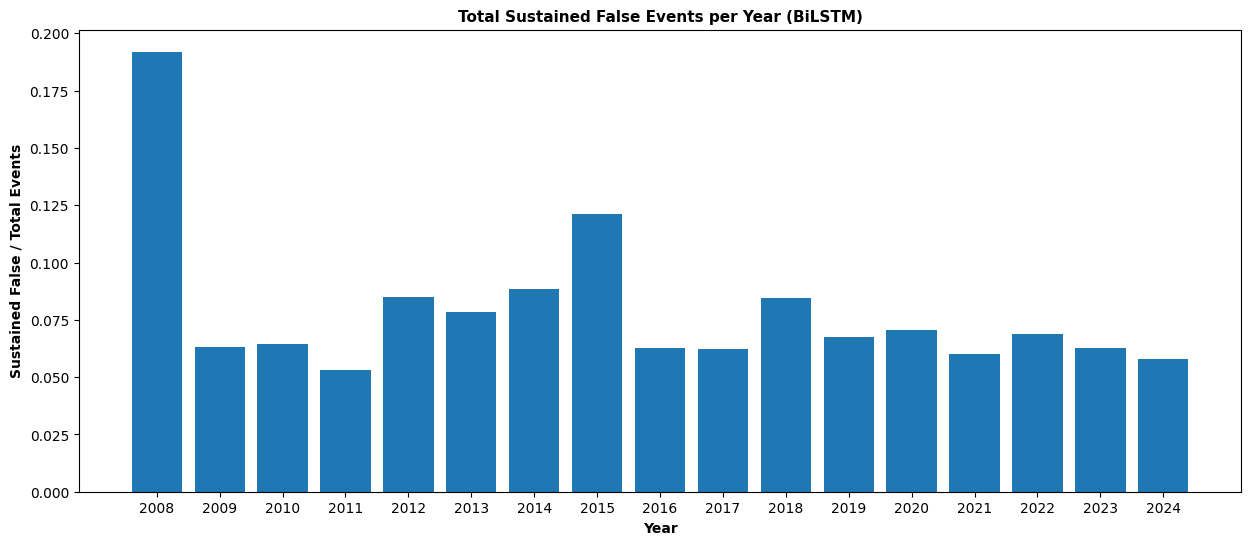

In [49]:
all_events = pd.to_datetime(event_df['start_time']).dt.year.value_counts().sort_index()
events_sus_false = pd.to_datetime(df['Time'].loc[sustained_false_df['start_idx']])
yearly_counts = events_sus_false.dt.year.value_counts().sort_index()

ratio_false_true = (yearly_counts / all_events)
years = ratio_false_true.index

plt.figure(figsize=(15, 6))
plt.bar(years, ratio_false_true)

plt.xticks(ticks=years, labels=years.astype(int), rotation=0)

plt.xlabel('Year', fontweight='bold')
plt.ylabel('Sustained False / Total Events', fontweight='bold')
plt.title('Total Sustained False Events per Year (BiLSTM)', fontsize=11, fontweight='bold')
plt.show()

In [50]:
def render_into_axes(ax, summary_df, title_prefix, y2_mode='features', velocity_ylim=(0, 90)):
    n_bins = len(summary_df)
    positions = np.arange(n_bins)

    bxp_stats = []
    for _, row in summary_df.iterrows():
        bxp_stats.append({
            'med': row['prob_med'],
            'q1': row['prob_q25'],
            'q3': row['prob_q75'],
            'whislo': row['prob_q05'],
            'whishi': row['prob_q95'],
            'fliers': []
        })

    ax.bxp(
        bxp_stats,
        positions=positions,
        widths=0.38,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='#d3d3d7', edgecolor='#b0b0b8', linewidth=1.0),
        medianprops=dict(color='#2b3a4a', linewidth=2.0),
        whiskerprops=dict(color='#404040', linestyle='--', linewidth=1.0),
        capprops=dict(color='#202020', linewidth=1.2)
    )

    ax.set_ylim(-0.02, 1.05)
    ax.set_ylabel(r"Predicted Probability (IQR & 5–95%)", fontsize=10, fontweight='bold')
    ax.set_xticks(positions)
    
    if "FP" in title_prefix:
        bin_labels = [
            "Short\nFalse\n(<10 min)",
            "Sustained\nFalse\n($\geq$10 min)",
            "Effectively\nFalse\n(<50% True)",
            "Genuine\nMixed\n($\geq$50% True)"
        ]
    else:
        bin_labels = [
            "Fully\nMissed\n($\leq$5%)",
            "Mostly\nMissed\n(5–40%)",
            "Partially\nCaptured\n(40–70%)",
            "Mostly\nCaptured\n(70–95%)",
            "Fully\nCaptured\n(>95%)"
        ]
    ax.set_xticklabels(bin_labels[:n_bins], fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    ax2 = ax.twinx()

    if y2_mode == 'features':
        ax.set_title(f"{title_prefix}: Features vs Predicted Probabilities", fontsize=11, fontweight='bold', pad=10)
        ax2.set_ylabel(r"Volatility", fontsize=10, color='indigo', fontweight='bold')
        ax2.set_ylim(0.0, 0.75)

        ax2.plot(positions, summary_df['Median Bx_vol'], color='blue', marker='o', linewidth=2.0, label=r"Median $B_x$ Vol")
        ax2.plot(positions, summary_df['Median By_vol'], color='limegreen', marker='o', linewidth=2.0, label=r"Median $B_y$ Vol")
        ax2.plot(positions, summary_df['Median Bz_vol'], color='red', marker='o', linewidth=2.0, label=r"Median $B_z$ Vol")

        # Plot 3 LIM scales (dashed lines with square markers)
        ax2.plot(positions, summary_df['Median Bx_std'], color='#80cbc4', marker='s', linestyle='--', linewidth=1.8, label=r"Median $B_x$ Std")
        ax2.plot(positions, summary_df['Median By_std'], color='#00796b', marker='s', linestyle='--', linewidth=1.8, label=r"Median $B_y$ Std")
        ax2.plot(positions, summary_df['Median Bz_std'], color='#004d40', marker='s', linestyle='--', linewidth=1.8, label=r"Median $B_z$ Std")

        ax2.legend(loc='upper left', ncol=2, frameon=True, fontsize=8)
        
        ax2.tick_params(axis='y', colors='indigo')

    elif y2_mode == 'velocity':
        ax.set_title(f"{title_prefix}: Velocity vs Predicted Probabilities", fontsize=11, fontweight='bold', pad=10)
        ax2.set_ylabel(r"V$_\perp$ (km/s)", fontsize=10, color='deeppink', fontweight='bold')
        ax2.set_ylim(velocity_ylim)

        # Velocity curve (magenta-red line with diamond markers)
        ax2.plot(positions, summary_df['Median V_perp'], color='deeppink', marker='D', linewidth=2.2, label=r"Median $V_\perp$")
        
        # 30 km/s reference threshold
        ax2.axhline(30, color='gray', linestyle='--', linewidth=1.2, label=r"$V_{\mathrm{low}} = 30\ \mathrm{km/s}$")

        ax2.tick_params(axis='y', colors='deeppink')
        ax2.legend(loc='upper left', frameon=True, fontsize=8.5)

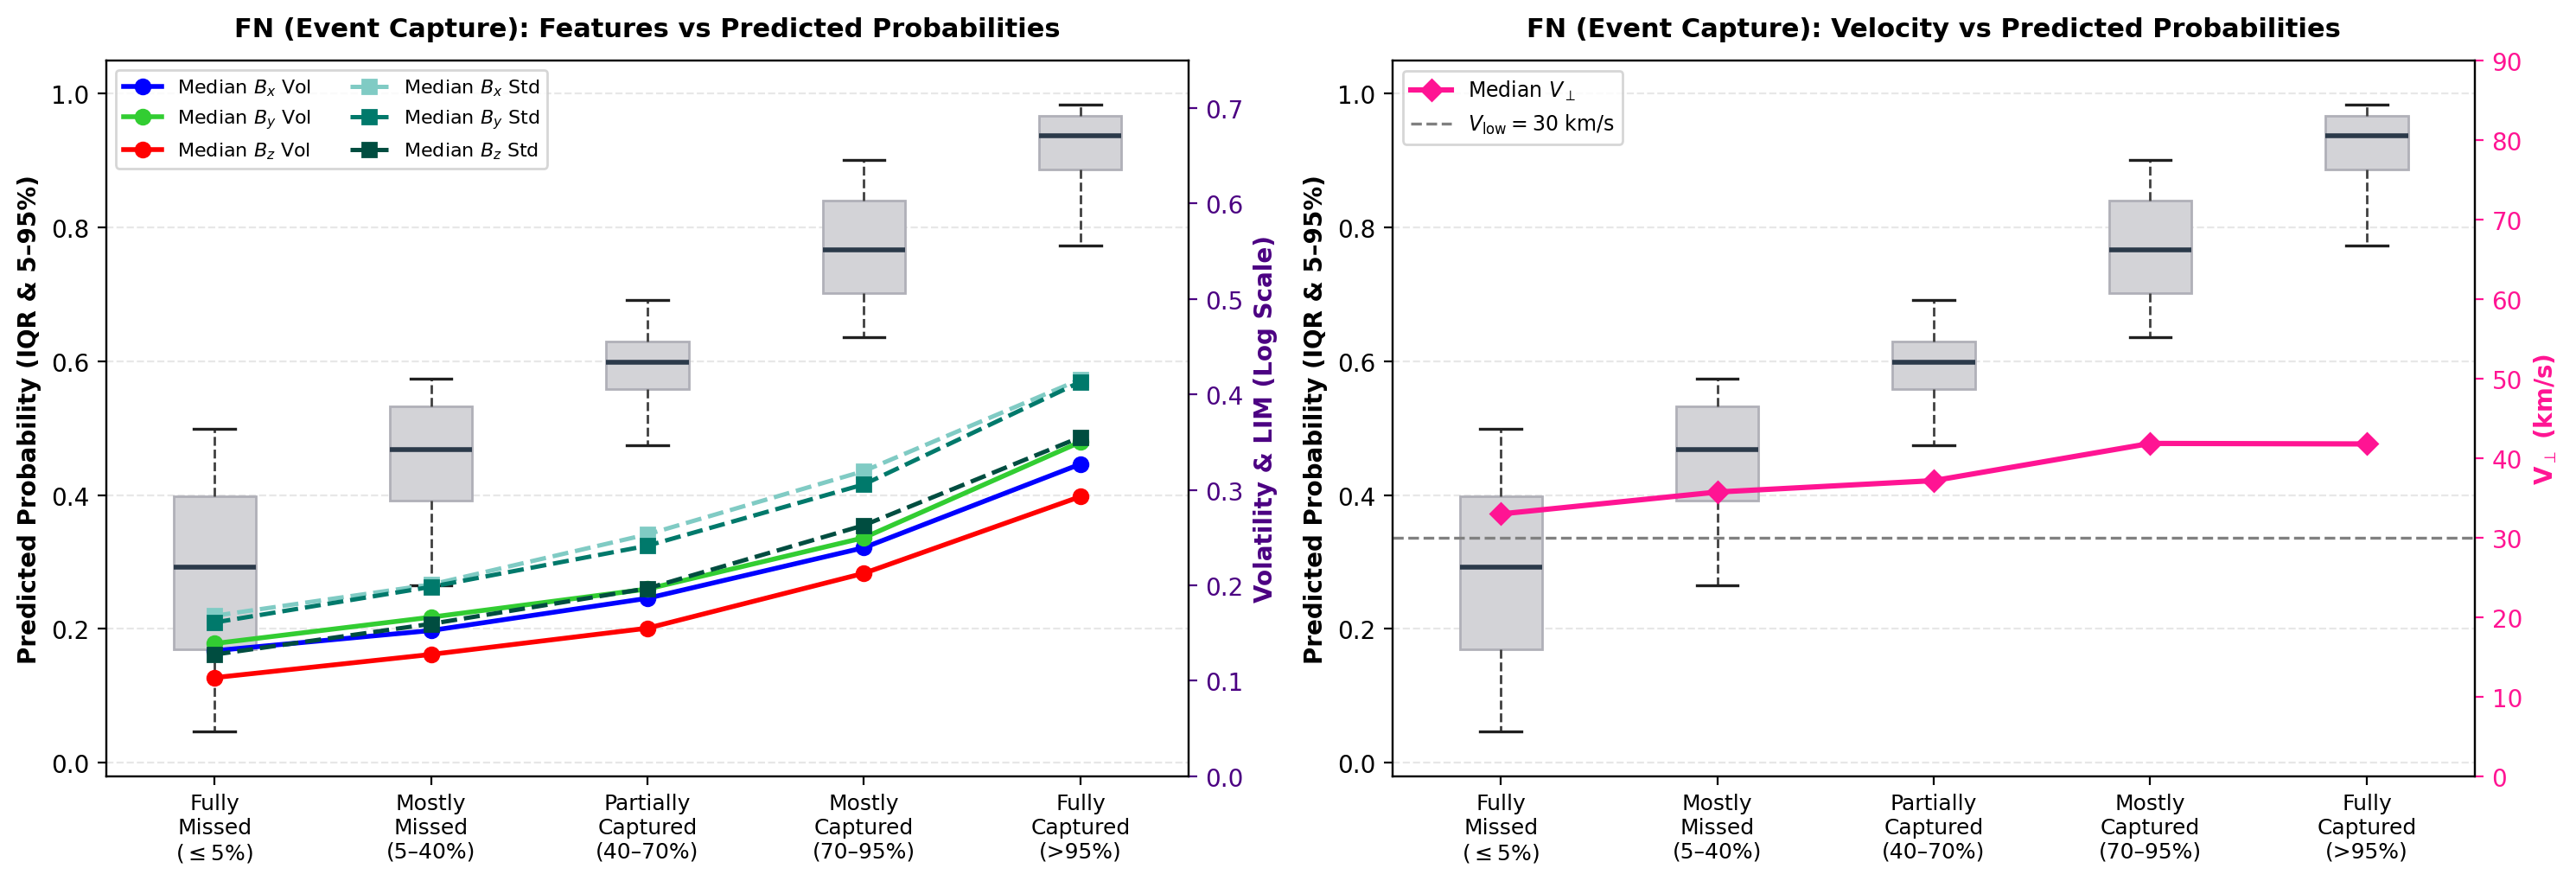

In [42]:
fig_fn, (ax_fn1, ax_fn2) = plt.subplots(1, 2, figsize=(15, 5.2), dpi=200)

render_into_axes(ax_fn1, fn_summary_df, "FN (Event Capture)", y2_mode='features')
render_into_axes(ax_fn2, fn_summary_df, "FN (Event Capture)", y2_mode='velocity', velocity_ylim=(0, 90))

plt.tight_layout()
plt.show()

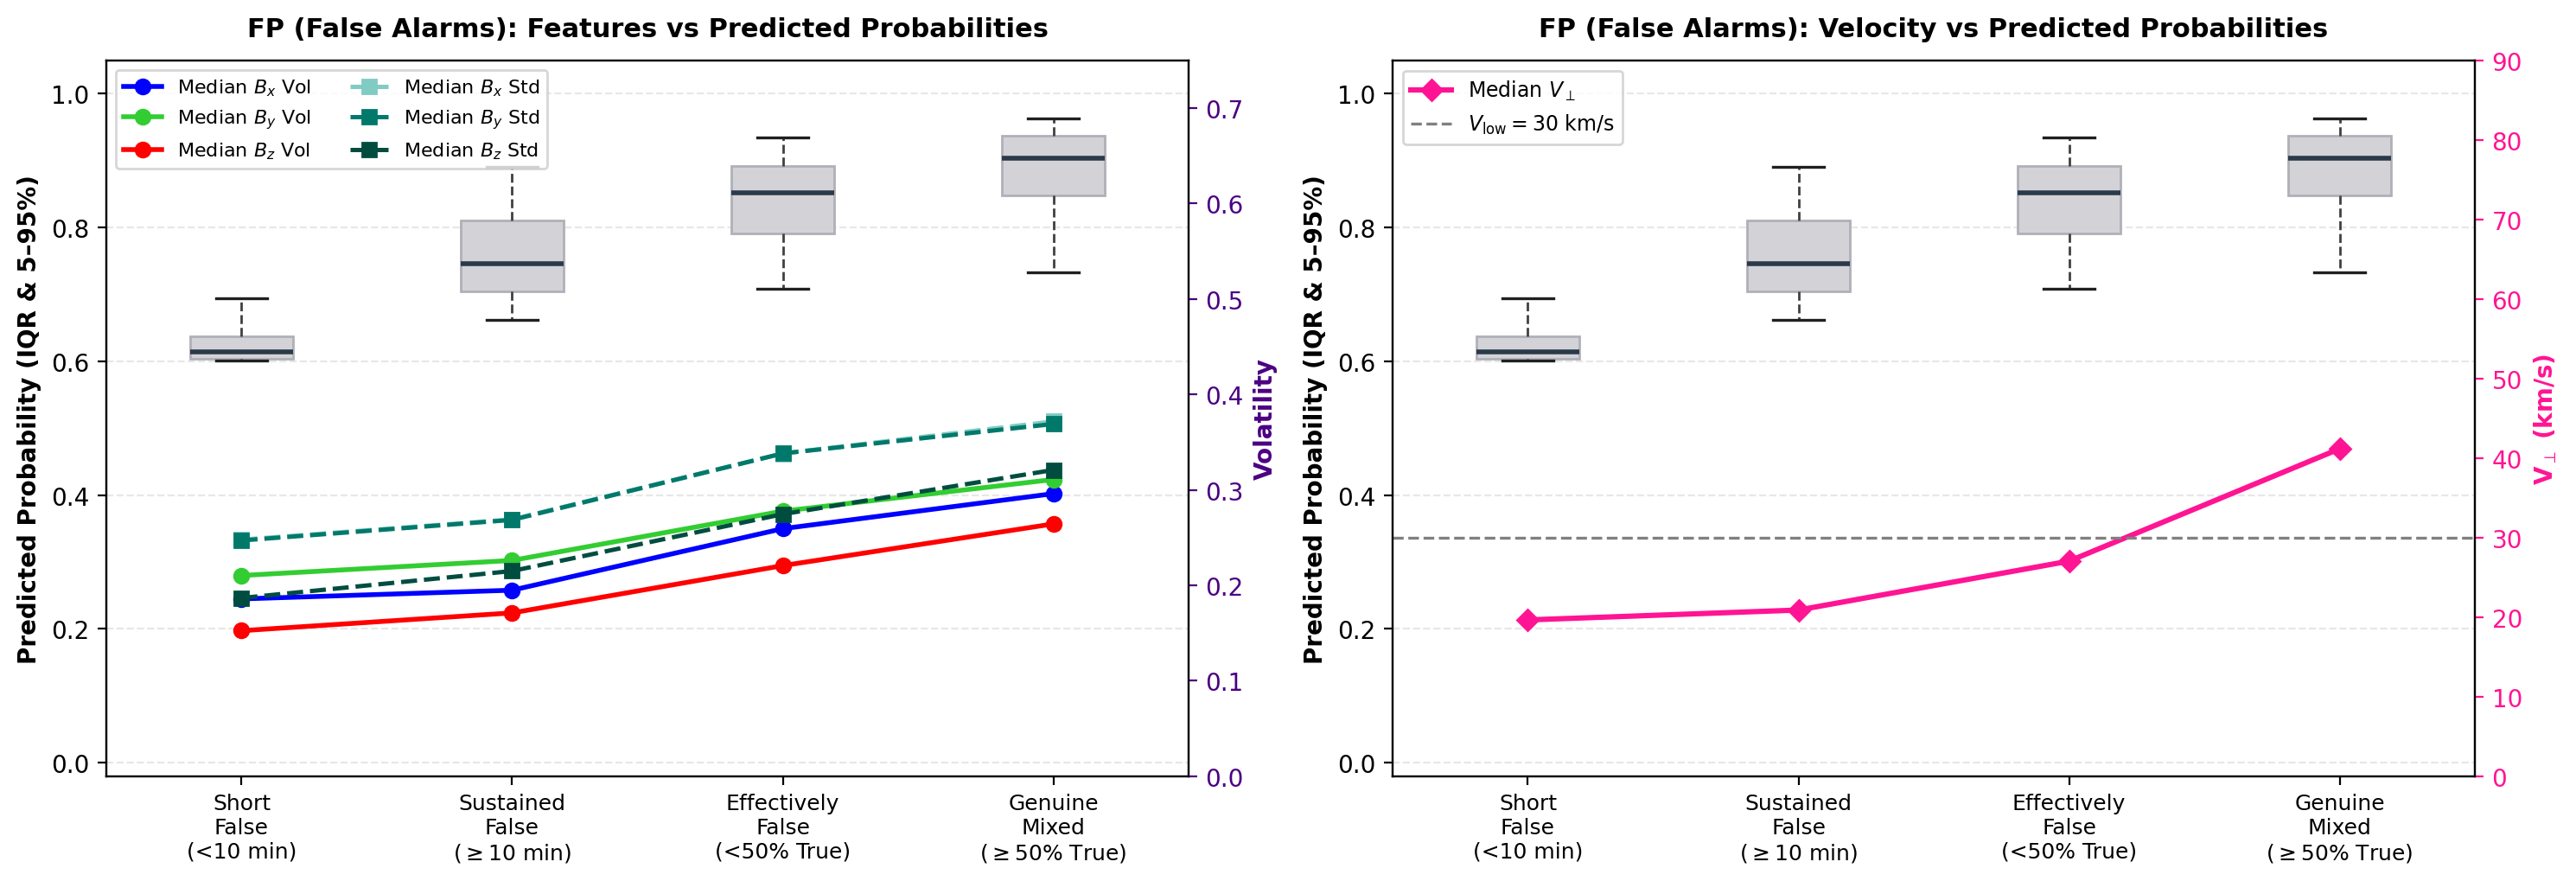

In [51]:
# Create 1x2 layout for FP Analysis
fig_fp, (ax_fp1, ax_fp2) = plt.subplots(1, 2, figsize=(15, 5.2), dpi=200)

render_into_axes(ax_fp1, fp_summary_df, "FP (False Alarms)", y2_mode='features')
render_into_axes(ax_fp2, fp_summary_df, "FP (False Alarms)", y2_mode='velocity', velocity_ylim=(0, 90))

plt.tight_layout()
plt.show()

In [44]:
pred_mask = (df["Event_pred"].values == 1).astype(int)
labeled_preds, num_pred_intervals = label(pred_mask)

slices = find_objects(labeled_preds)  # list of 1-tuples of slice objects
pred_starts = np.array([s[0].start for s in slices])
pred_ends = np.array([s[0].stop - 1 for s in slices])

true_arr = (df["Event_label_80"].values == 1)
pred_arr = (df["Event_pred"].values == 1)
and_arr = true_arr & pred_arr

# prefix[k] = sum(arr[0:k])  (len = N+1, prefix[0] = 0)
true_prefix = np.concatenate(([0], np.cumsum(true_arr)))
pred_prefix = np.concatenate(([0], np.cumsum(pred_arr)))
and_prefix = np.concatenate(([0], np.cumsum(and_arr)))


def window_sum(prefix, start, end):
    """Vectorized inclusive-range sum: sum(arr[start:end+1]) for arrays of starts/ends."""
    return prefix[end + 1] - prefix[start]


event_start_labels = np.array([idx[0] for idx in event_indices])
event_end_labels = np.array([idx[-1] for idx in event_indices])

event_starts = df.index.get_indexer(event_start_labels)
event_ends = df.index.get_indexer(event_end_labels)

if (event_starts == -1).any() or (event_ends == -1).any():
    raise ValueError(
        "Some event_indices labels were not found in df.index — "
        "check that event_indices actually refers to df's index labels."
    )
event_classes_arr = np.asarray(event_classes)
event_years_arr = np.asarray(event_years)
n_events = len(event_indices)

overlap = (pred_ends[None, :] >= event_starts[:, None]) & (
    pred_starts[None, :] <= event_ends[:, None]
)

frag_count = overlap.sum(axis=1)
has_overlap = frag_count > 0

first_pred_idx = np.argmax(overlap, axis=1)
last_pred_idx = overlap.shape[1] - 1 - np.argmax(overlap[:, ::-1], axis=1)

u_start = np.minimum(event_starts, pred_starts[first_pred_idx])
u_end = np.maximum(event_ends, pred_ends[last_pred_idx])

true_sum = window_sum(true_prefix, u_start, u_end)
pred_sum = window_sum(pred_prefix, u_start, u_end)
inter_sum = window_sum(and_prefix, u_start, u_end)
union_sum = true_sum + pred_sum - inter_sum

iou = np.where(union_sum > 0, inter_sum / np.maximum(union_sum, 1), 0.0)

dt_minutes = 60.0
onset_delay = (pred_starts[first_pred_idx] - event_starts) / dt_minutes
offset_delay = (pred_ends[last_pred_idx] - event_ends) / dt_minutes

iou = np.where(has_overlap, iou, 0.0)
onset_delay = np.where(has_overlap, onset_delay, np.nan)
offset_delay = np.where(has_overlap, offset_delay, np.nan)
frag_count = np.where(has_overlap, frag_count, 0)

iou_df = pd.DataFrame(
    {
        "event_id": np.arange(n_events),
        "event_class": event_classes_arr,
        "year": event_years_arr,
        "iou": iou,
        "frag_count": frag_count,
        "onset_delay_min": onset_delay,
        "offset_delay_min": offset_delay,
    }
)

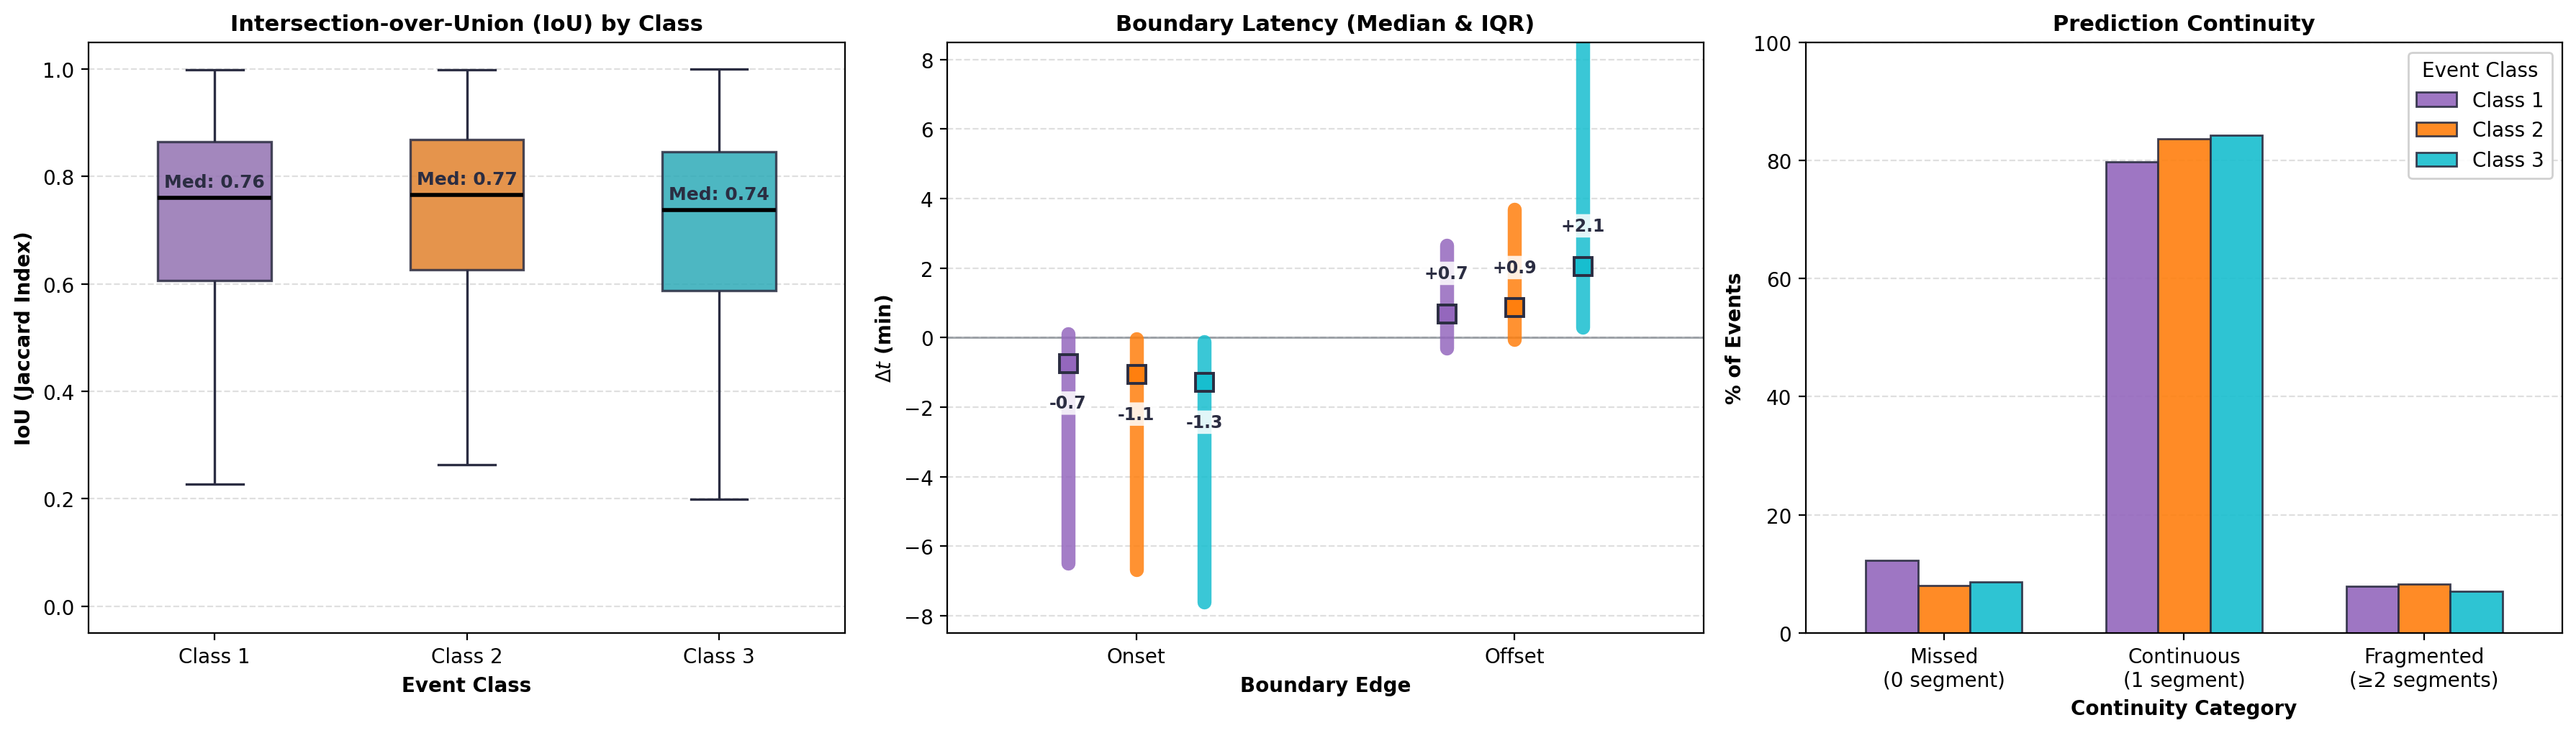

In [45]:
class_palette = ["C4", "C1", "C9"]  # Class 1: C4, Class 2: C1, Class 3: C9

# Prepare captured events & reshape delay for grouped boxplot
captured_events = iou_df[iou_df["iou"] > 0].copy()

delay_melted = captured_events.melt(
    id_vars=["event_class"],
    value_vars=["onset_delay_min", "offset_delay_min"],
    var_name="boundary_type",
    value_name="delay_min",
)
delay_melted["boundary_type"] = delay_melted["boundary_type"].map(
    {"onset_delay_min": "Onset", "offset_delay_min": "Offset"}
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.2), dpi=200)

# =============================================================
# Panel 1: IoU Distributions
# =============================================================
sns.boxplot(
    data=captured_events,
    x="event_class",
    y="iou",
    hue="event_class",
    palette=class_palette,
    legend=False,
    ax=ax1,
    width=0.45,
    boxprops=dict(alpha=0.85, edgecolor="#2b2d42", linewidth=1.2),
    medianprops=dict(color="black", linewidth=2.0),
    whiskerprops=dict(color="#2b2d42", linewidth=1.2),
    capprops=dict(color="#2b2d42", linewidth=1.2),
    showfliers=False,
)

medians_iou = captured_events.groupby("event_class")["iou"].median()
for cls_idx, med_val in medians_iou.items():
    ax1.text(
        cls_idx - 1,
        med_val + 0.02,
        f"Med: {med_val:.2f}",
        horizontalalignment="center",
        weight="bold",
        fontsize=9,
        color="#2b2d42",
    )

ax1.set_title(
    "Intersection-over-Union (IoU) by Class", weight="bold", fontsize=11
)
ax1.set_xlabel("Event Class", weight="bold", fontsize=10)
ax1.set_ylabel("IoU (Jaccard Index)", weight="bold", fontsize=10)
ax1.set_xticks(range(len(medians_iou)))
ax1.set_xticklabels(["Class 1", "Class 2", "Class 3"])
ax1.set_ylim(-0.05, 1.05)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# =============================================================
# Panel 2: Styled Interval Range (Thick stems + Square medians)
# =============================================================
ax2.axhline(0, color="#6c757d", linestyle="-", linewidth=1.1, alpha=0.6)

latency_stats = (
    delay_melted.groupby(["boundary_type", "event_class"])["delay_min"]
    .agg(
        med="median",
        q25=lambda x: np.percentile(x.dropna(), 25),
        q75=lambda x: np.percentile(x.dropna(), 75),
    )
    .reset_index()
)

boundary_map = {"Onset": 0, "Offset": 1}
offsets_x = [-0.18, 0.0, 0.18]

for i, boundary in enumerate(["Onset", "Offset"]):
    for j, cls in enumerate([1, 2, 3]):
        row = latency_stats[
            (latency_stats["boundary_type"] == boundary)
            & (latency_stats["event_class"] == cls)
        ].iloc[0]

        x_pos = boundary_map[boundary] + offsets_x[j]
        color = class_palette[j]

        # Extra-thick, solid color-matched IQR span bar
        ax2.vlines(
            x_pos,
            row["q25"],
            row["q75"],
            color=color,
            linewidth=7.0,  # Significantly thicker
            alpha=0.85,
            capstyle="round",
        )

        # Median rendered as a crisp square
        ax2.plot(
            x_pos,
            row["med"],
            marker="s",  # Square marker
            markersize=9,  # Larger footprint to fit the thick stem
            color=color,
            markeredgecolor="#2b2d42",
            markeredgewidth=1.4,
            zorder=4,
        )

        # Clean annotation offset
        y_text = row["med"] - 1.15 if boundary == "Onset" else row["med"] + 1.15
        ax2.text(
            x_pos,
            y_text,
            f"{row['med']:+.1f}",
            ha="center",
            va="center",
            fontsize=8.5,
            weight="bold",
            color="#2b2d42",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
        )

ax2.set_title("Boundary Latency (Median & IQR)", weight="bold", fontsize=11)
ax2.set_xlabel("Boundary Edge", weight="bold", fontsize=10)
ax2.set_ylabel(r"$\Delta t$ (min)", weight="bold", fontsize=10)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Onset", "Offset"])
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-8.5, 8.5)
ax2.set_axisbelow(True)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# =============================================================
# Panel 3: Continuity Grouped by Regime
# =============================================================
frag_counts = (
    pd.crosstab(iou_df["event_class"], iou_df["frag_count"], normalize="index")
    * 100
)

if 0 not in frag_counts.columns:
    frag_counts[0] = 0.0
frag_counts["≥2 (Fragmented)"] = frag_counts.loc[
    :, [c for c in frag_counts.columns if isinstance(c, (int, np.integer)) and c >= 2]
].sum(axis=1)

frag_plot_data = frag_counts[[0, 1, "≥2 (Fragmented)"]].rename(
    columns={
        0: "Missed\n(0 segment)",
        1: "Continuous\n(1 segment)",
        "≥2 (Fragmented)": "Fragmented\n(≥2 segments)",
    },
    index={1: "Class 1", 2: "Class 2", 3: "Class 3"},
)

transposed_plot_data = frag_plot_data.T

transposed_plot_data.plot(
    kind="bar",
    stacked=False,
    ax=ax3,
    color=class_palette,
    edgecolor="#2b2d42",
    linewidth=1.0,
    width=0.65,
    alpha=0.9,
)

ax3.set_title(
    "Prediction Continuity", weight="bold", fontsize=11
)
ax3.set_xlabel("Continuity Category", weight="bold", fontsize=10)
ax3.set_ylabel("% of Events", weight="bold", fontsize=10)
ax3.set_xticklabels(transposed_plot_data.index, rotation=0)
ax3.set_ylim(0, 100)
ax3.legend(title="Event Class", loc="upper right", framealpha=0.9)
ax3.set_axisbelow(True)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

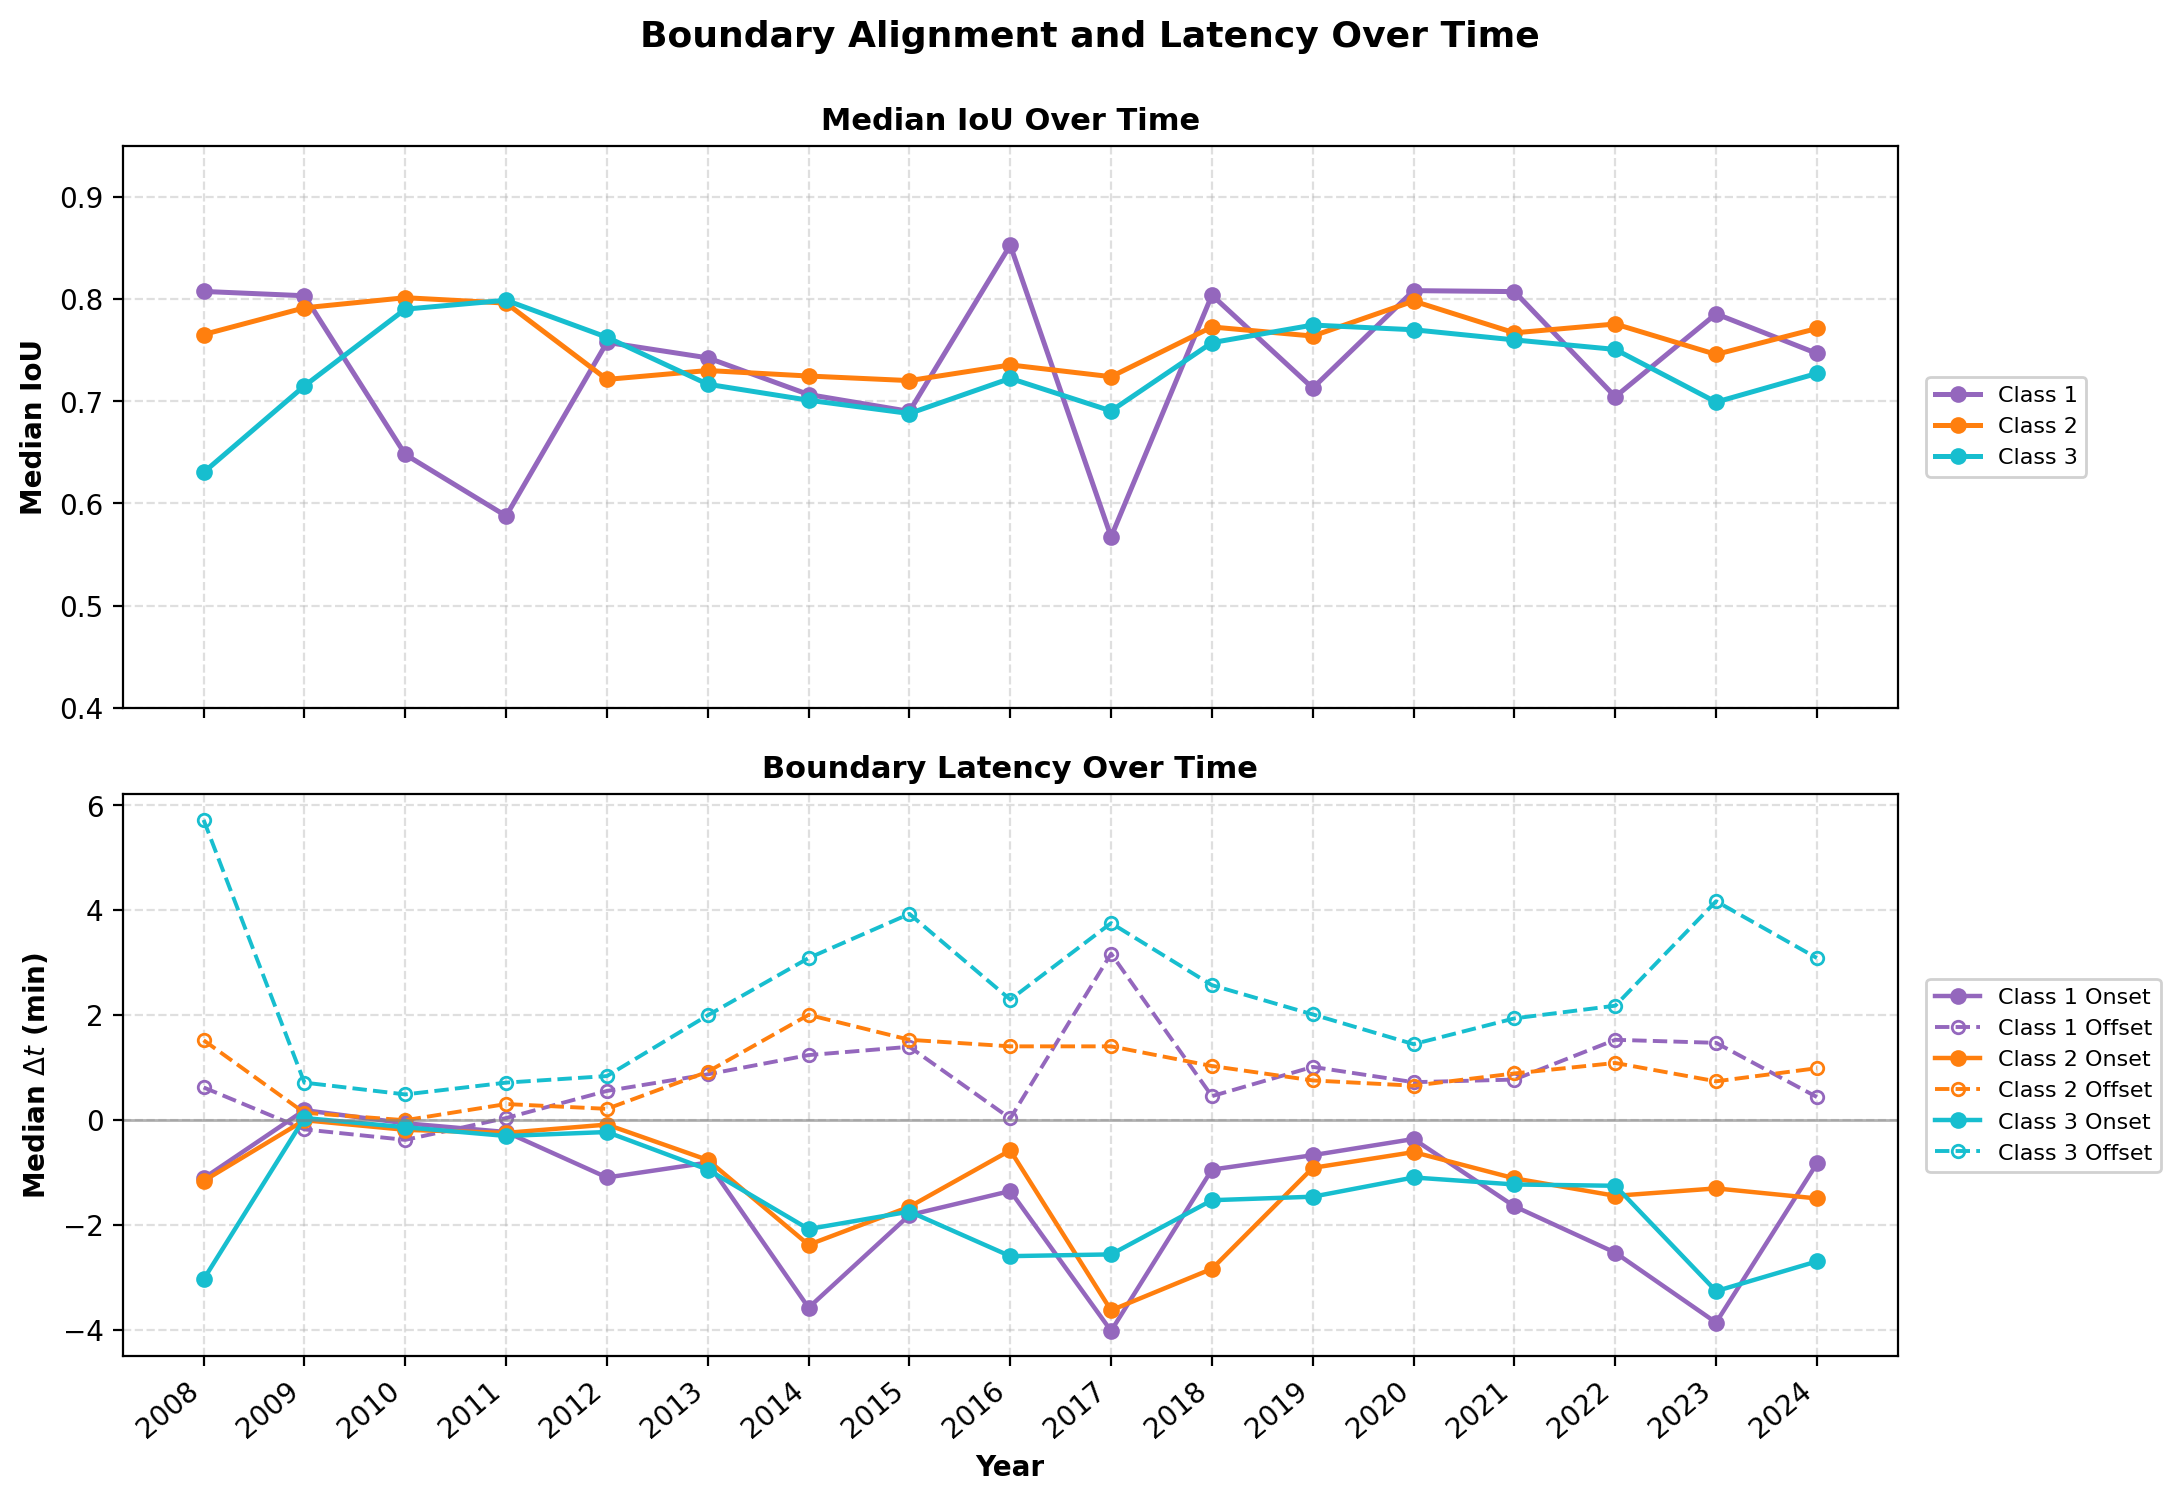

In [46]:
years = np.sort(iou_df["year"].unique())
classes = [1, 2, 3]
class_colors = {1: "C4", 2: "C1", 3: "C9"}
class_labels = {1: "Class 1", 2: "Class 2", 3: "Class 3"}

iou_yearly = (
    iou_df[iou_df["iou"] > 0]
    .groupby(["year", "event_class"])["iou"]
    .median()
    .unstack()
)

onset_yearly = (
    iou_df.groupby(["year", "event_class"])["onset_delay_min"].median().unstack()
)
offset_yearly = (
    iou_df.groupby(["year", "event_class"])["offset_delay_min"]
    .median()
    .unstack()
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7.5), sharex=True, dpi=200
)

for c in classes:
    color = class_colors[c]
    label = class_labels[c]

    # Panel 1: Median IoU (Solid, Circle)
    if c in iou_yearly.columns:
        ax1.plot(
            iou_yearly.index,
            iou_yearly[c],
            marker="o",
            markersize=5,
            linewidth=1.8,
            color=color,
            label=label,
        )

    # Panel 2 (formerly Panel 3): Boundary Latency (Onset: Solid Circle, Offset: Dotted Circle)
    if c in onset_yearly.columns:
        ax2.plot(
            onset_yearly.index,
            onset_yearly[c],
            marker="o",
            markersize=5,
            linewidth=1.6,
            color=color,
            label=f"{label} Onset",
        )
    if c in offset_yearly.columns:
        ax2.plot(
            offset_yearly.index,
            offset_yearly[c],
            marker="o",
            markersize=4.5,
            linewidth=1.4,
            linestyle="--",
            markerfacecolor="none",
            color=color,
            label=f"{label} Offset",
        )

# Panel 1 Formatting: IoU
ax1.set_ylabel("Median IoU", weight="bold", fontsize=10)
ax1.set_title("Median IoU Over Time", weight="bold", fontsize=11, pad=6)
ax1.set_ylim(0.4, 0.95)
ax1.set_axisbelow(True)
ax1.grid(axis="both", linestyle="--", alpha=0.4)
ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), framealpha=0.9, fontsize=8)

# Panel 2 Formatting: Edge Delays
ax2.axhline(0, color="gray", linestyle="-", linewidth=1.0, alpha=0.6)
ax2.set_ylabel(r"Median $\Delta t$ (min)", weight="bold", fontsize=10)
ax2.set_title("Boundary Latency Over Time", weight="bold", fontsize=11, pad=6)
ax2.set_xlabel("Year", weight="bold", fontsize=10)
ax2.set_xticks(years)
ax2.set_xticklabels(years, rotation=40, ha="right")
ax2.set_axisbelow(True)
ax2.grid(axis="both", linestyle="--", alpha=0.4)
ax2.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), framealpha=0.9, fontsize=8)

fig.suptitle(
    "Boundary Alignment and Latency Over Time",
    weight="bold",
    fontsize=13,
    y=0.995,
)

plt.tight_layout()
plt.show()

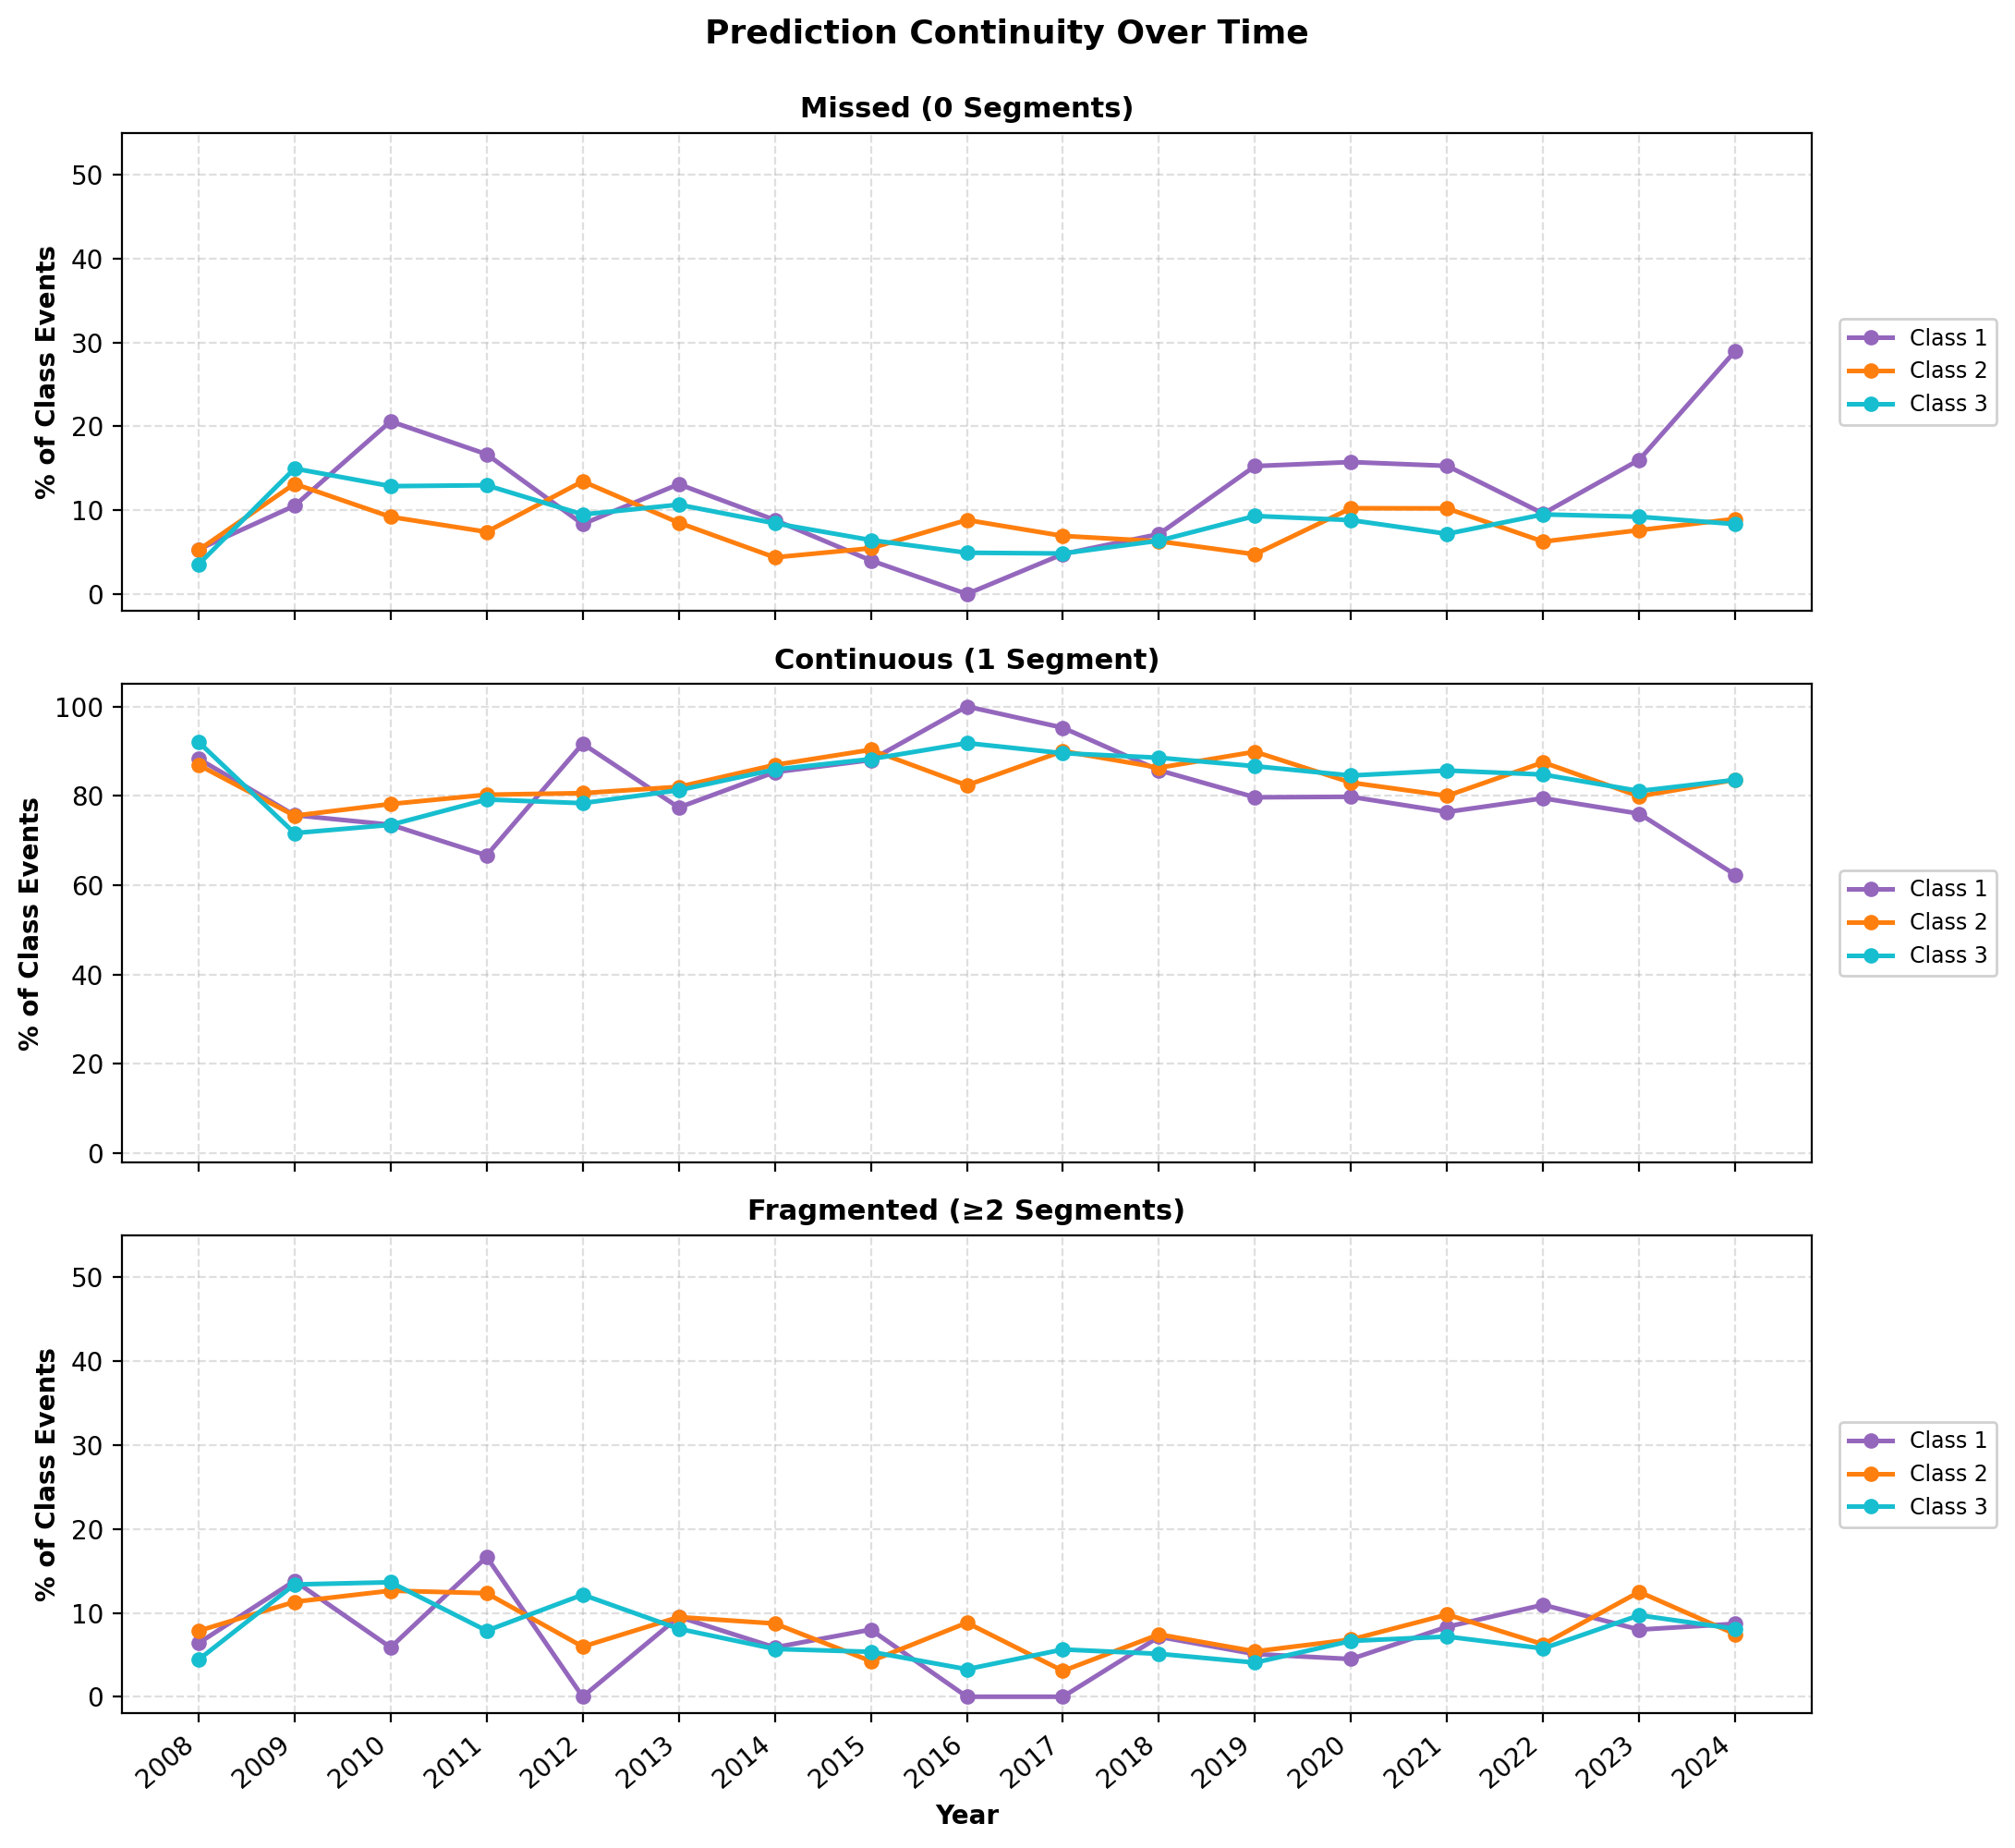

In [47]:
years = np.sort(iou_df["year"].unique())
classes = [1, 2, 3]
class_colors = {1: "C4", 2: "C1", 3: "C9"}
class_labels = {1: "Class 1", 2: "Class 2", 3: "Class 3"}

frag_grouped = (
    iou_df.groupby(["year", "event_class"])["frag_count"]
    .agg(
        total="count",
        missed=lambda x: (x == 0).sum(),
        unbroken=lambda x: (x == 1).sum(),
        fragmented=lambda x: (x >= 2).sum(),
    )
    .reset_index()
)

frag_grouped["pct_missed"] = (
    frag_grouped["missed"] / frag_grouped["total"]
) * 100
frag_grouped["pct_unbroken"] = (
    frag_grouped["unbroken"] / frag_grouped["total"]
) * 100
frag_grouped["pct_fragmented"] = (
    frag_grouped["fragmented"] / frag_grouped["total"]
) * 100

pct_missed_pivot = frag_grouped.pivot(
    index="year", columns="event_class", values="pct_missed"
)
pct_unbroken_pivot = frag_grouped.pivot(
    index="year", columns="event_class", values="pct_unbroken"
)
pct_fragmented_pivot = frag_grouped.pivot(
    index="year", columns="event_class", values="pct_fragmented"
)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(11, 10), sharex=True, dpi=200
)

panels = [
    (ax1, pct_missed_pivot, "Missed (0 Segments)", 55),
    (ax2, pct_unbroken_pivot, "Continuous (1 Segment)", 105),
    (ax3, pct_fragmented_pivot, "Fragmented (≥2 Segments)", 55),
]

for ax, pivot_df, title, y_max in panels:
    for c in classes:
        if c in pivot_df.columns:
            ax.plot(
                pivot_df.index,
                pivot_df[c],
                marker="o",
                markersize=5,
                linewidth=1.8,
                color=class_colors[c],
                label=class_labels[c],
            )

    ax.set_ylabel("% of Class Events", weight="bold", fontsize=10)
    ax.set_ylim(-2, y_max)
    ax.set_title(title, weight="bold", fontsize=11, pad=6)
    ax.set_axisbelow(True)
    ax.grid(axis="both", linestyle="--", alpha=0.4)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        framealpha=0.9,
        fontsize=8.5,
    )

ax3.set_xlabel("Year", weight="bold", fontsize=10)
ax3.set_xticks(years)
ax3.set_xticklabels(years, rotation=40, ha="right")

fig.suptitle(
    "Prediction Continuity Over Time",
    weight="bold",
    fontsize=13,
    y=0.995,
)

plt.tight_layout()
plt.show()